---
# 프로젝트 수행: KoChatGPT 업그레이드

## 채택한 업그레이드 전략과 루브릭 매핑

| 학습목표(루브릭) | 평가기준 | 이 프로젝트에서 수행한 것 |
|---|---|---|
| **1. 정량적 성능 향상** | ① 기존 데이터셋 추가 정제 + 디코딩 기법 실험 | Step 1~2: EDA→정제(아티팩트 제거·잘림 복구·중복 제거), Step 4: Greedy/Beam/Top-k/Top-p/Temperature 그리드 실험 |
| | ② 새로운 데이터 수집·전처리 | Step 2: **KorQuAD 1.0** 수집 → 독해(RC) instruction 형식으로 전처리·증강 (정제로 줄어든 크기 복원 + α) |
| | ③ 더 적절한 학습 전략 / initial model 변경 | Step 3: SFT 학습전략 개선(멀티에폭·cosine 스케줄·eval split·pad 토큰 분리), Step 6: **RM 랭킹 라벨 해석 오류 수정(페어 22.5% 라벨 뒤집힘 교정)** + 학습 데이터 5배 확대, (부록) ko-gpt-trinity-1.2B 교체 |
| **2. SFT vs RM 결과 분석** | 정량/정성 비교 | Step 6: RM 자체 성능(정확도·reward 분포) 분석, Step 8: SFT 모델 vs RM 기반 PPO 모델 생성문 비교(BLEU/ROUGE/Distinct/RM-reward + 정성 표) |
| **3. 기존 KoGPT2 vs SFT 분석** | 정량/정성 비교 | Step 5: KoGPT2(사전학습 원본) vs SFT 모델의 PPL·BLEU·ROUGE 정량 비교 + 동일 프롬프트 정성 비교 |

## 진행 순서 (Colab T4 기준 예상 소요시간)

| Step | 내용 | 예상 시간 |
|---|---|---|
| 0 | 환경 준비(독립 실행 가능하도록 재설정) | ~3분 |
| 1 | 데이터셋 EDA — 무엇이 문제인지 *숫자로* 확인 | ~2분 |
| 2 | 데이터 정제 + KorQuAD 증강 → `data_kochatgpt_v2` 저장 | ~3분 |
| 3 | 개선된 SFT 학습 (+ 필요시 베이스라인 SFT) | ~30분 |
| 4 | 디코딩 하이퍼파라미터 실험 (Beam/Top-k/Top-p…) | ~10분 |
| 5 | 정량 평가: **KoGPT2 vs SFT** (루브릭 목표 3) | ~15분 |
| 6 | 개선된 RM 학습 + RM 분석 (루브릭 목표 2 전반) | ~25분 |
| 7 | PPO 학습 (RM을 정책에 반영) | ~20분 |
| 8 | 최종 비교: **SFT vs PPO(RM 적용)** + 종합 정량표 (루브릭 목표 2) | ~10분 |
| 9 | 결론 및 회고 | - |
| 부록 | foundation model 교체(ko-gpt-trinity-1.2B, 선택) | ~40분+ |

## Step 0. 환경 준비

**이 셀부터 새 런타임에서도 실행 가능**하도록 설치→클론→패치→임포트를 한 번에 다시 수행합니다(이미 실행된 상태면 각 단계는 자동으로 건너뜁니다).

`[변경]` 강의 코드와 달라진 점
- 설치/클론/패치에 **존재 여부 가드**를 붙여 몇 번을 재실행해도 안전(멱등)하게 만들었습니다.
- 전 구간 재현성을 위해 **시드 고정 함수** `set_all_seeds()`를 추가했습니다.
- GPU 메모리 부족(OOM) 대비용 `free_gpu()` 헬퍼를 추가했습니다.
- transformers 버전에 따라 인자 이름이 다른 문제(`evaluation_strategy` ↔ `eval_strategy`)를 흡수하는 `make_training_args()`를 추가했습니다.

In [ ]:
# ============================================================
# Step 0. 환경 준비 (멱등: 재실행해도 안전)
# ============================================================
import os, sys, json, re, random, copy, math, unicodedata, subprocess
from collections import Counter

# ── (0) HF 다운로드 안정화: Xet 백엔드 비활성화 ──────────────
# 일부 Colab 환경에서 huggingface_hub의 Xet 다운로드가 중간(예: 78%)에서
# 무한 대기하는 문제가 있다 → 검증된 일반 HTTP 다운로드로 강제 전환한다.
# (env 변수는 임포트 전용, constants 패치는 이미 임포트된 경우용 — 둘 다 적용)
os.environ['HF_HUB_DISABLE_XET'] = '1'
try:
    from huggingface_hub import constants as _hf_constants
    _hf_constants.HF_HUB_DISABLE_XET = True
    print('[hf-fix] Xet 다운로드 비활성화 → 일반 HTTP 다운로드 사용')
except Exception:
    pass

# ── (1) 라이브러리 설치 ──────────────────────────────────────
# [기존] !pip install datasets / loralib / trl 를 매번 실행
# [변경] import 실패 시에만 설치 (재실행 시 시간 절약)
def _ensure(pkg, pip_name=None):
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pip_name or pkg], check=False)

_ensure('datasets')
_ensure('loralib')

# ── (2) KoChatGPT 저장소 클론 + chatgpt 패키지 준비 ─────────
# [기존] !git clone ... 을 무조건 실행 (재실행 시 이미 존재 에러)
# [변경] 폴더 존재 여부를 확인하고 없을 때만 클론/복사
BASE = '/content'
if not os.path.exists(f'{BASE}/KoChatGPT'):
    subprocess.run(['git', 'clone', 'https://github.com/airobotlab/KoChatGPT', f'{BASE}/KoChatGPT'], check=True)
if not os.path.exists(f'{BASE}/chatgpt'):
    subprocess.run(['cp', '-r', f'{BASE}/KoChatGPT/colossalai_ChatGPT_230319/chatgpt', f'{BASE}/chatgpt'], check=True)
if BASE not in sys.path:
    sys.path.insert(0, BASE)

# ── (3) chatgpt 패키지 호환 패치 ─────────────────────────────
# [기존] 강의 셀의 modifications 코드와 동일한 역할
# [변경] "이미 패치되었는지"를 파일 내용으로 확인하는 멱등 패치로 재구성
def _patch_file(path, old, new):
    if not os.path.exists(path):
        print(f'⚠️ 파일 없음: {path}');  return
    with open(path, encoding='utf-8') as f:
        text = f.read()
    if old in text:
        with open(path, 'w', encoding='utf-8') as f:
            f.write(text.replace(old, new))
        print(f'✅ 패치: {path}')
    else:
        print(f'⏭️ 이미 패치됨(또는 대상 없음): {path}')

_patch_file(f'{BASE}/chatgpt/trainer/callbacks/save_checkpoint.py',
            'from chatgpt.trainer.strategies import ColossalAIStrategy, Strategy',
            'from chatgpt.trainer.strategies import Strategy')
_patch_file(f'{BASE}/chatgpt/trainer/callbacks/save_checkpoint.py',
            'only_rank0 = not isinstance(self.strategy, ColossalAIStrategy)',
            'only_rank0 = True')
_patch_file(f'{BASE}/chatgpt/trainer/strategies/__init__.py',
            'from .colossalai import ColossalAIStrategy\n', '')
_patch_file(f'{BASE}/chatgpt/trainer/strategies/__init__.py',
            "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy', 'ColossalAIStrategy']",
            "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy']")
for _f in ['dataset/reward_dataset.py', 'trainer/base.py', 'trainer/rm.py']:
    _patch_file(f'{BASE}/chatgpt/{_f}', 'from tqdm import tqdm', 'from tqdm.notebook import tqdm')

# ── (4) torch.load 호환 패치 (Colab 최신 torch 대응) ─────────
import torch as _t
_t._orig_load = getattr(_t, '_orig_load', _t.load)
def _compat_load(*a, **k):
    k.setdefault('weights_only', False)
    return _t._orig_load(*a, **k)
_t.load = _compat_load

# ── (5) 공통 임포트 & 디바이스 ──────────────────────────────
import numpy as np
import pandas as pd
import torch
import transformers
from transformers import AutoModelForCausalLM, PreTrainedTokenizerFast

device = 'cuda' if torch.cuda.is_available() else 'cpu'
assert device == 'cuda', 'GPU 런타임이 아닙니다! 런타임 유형을 GPU(T4 이상)로 변경하세요.'
print('torch:', torch.__version__, '| transformers:', transformers.__version__, '| device:', device)

# ── (6) [변경-신규] 재현성: 시드 고정 함수 ───────────────────
# 강의 코드에는 random.seed(230319) 한 줄뿐이었음 → torch/numpy/cudnn까지 통일
SEED = 230319
def set_all_seeds(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_all_seeds()

# ── (7) [변경-신규] GPU 메모리 정리 헬퍼 ────────────────────
# 단계 전환(SFT→RM→PPO) 때마다 이전 모델을 지워 T4 16GB에서 OOM 방지
import gc
def free_gpu(*names):
    g = globals()
    for n in names:
        if n in g:
            try: del g[n]
            except Exception: pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print(f'GPU 메모리: {torch.cuda.memory_allocated()/1e9:.2f} GB 사용 중')

# ── (8) [변경-신규] transformers 버전 호환 TrainingArguments ─
# 4.x: evaluation_strategy / 5.x: eval_strategy 로 인자명이 바뀌어 양쪽 지원
import inspect
def make_training_args(**kw):
    params = inspect.signature(transformers.TrainingArguments.__init__).parameters
    if 'evaluation_strategy' in kw and 'evaluation_strategy' not in params:
        kw['eval_strategy'] = kw.pop('evaluation_strategy')
    if 'eval_strategy' in kw and 'eval_strategy' not in params:
        kw['evaluation_strategy'] = kw.pop('eval_strategy')
    return transformers.TrainingArguments(**kw)

# ── (9) KoGPT2 토크나이저 로드 + 기능 가드 ───────────────────
# [기존] SFT 셀은 pad_token='</s>' 로 eos와 pad를 겸용
#        → DataCollator가 attention_mask = input_ids.ne(pad_id) 를 만들 때
#          문장 끝의 "진짜 eos"까지 마스킹되는 부작용이 있었음
# [변경] pad_token='<pad>' 로 분리 (KoGPT2 공식 특수토큰 사용)
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    'skt/kogpt2-base-v2',
    bos_token='</s>', eos_token='</s>', unk_token='<unk>',
    pad_token='<pad>', mask_token='<mask>',
    padding_side='right', model_max_length=512,
)
_rt = tokenizer.decode(tokenizer.encode('불고기용 고기 한우에요?'))
assert tokenizer.vocab_size == 51200 and '불고기' in _rt and '�' not in _rt, '토크나이저 로드 이상'
print('[tokenizer OK] vocab:', tokenizer.vocab_size,
      '| eos:', tokenizer.eos_token_id, '| pad:', tokenizer.pad_token_id)

# ── (10) 프로젝트 공통 상수 ─────────────────────────────────
DATA_DIR    = f'{BASE}/KoChatGPT/data_kochatgpt'   # 원본 데이터
DATA_V2_DIR = f'{BASE}/data_kochatgpt_v2'          # 정제/증강 데이터 저장 위치
os.makedirs(DATA_V2_DIR, exist_ok=True)

# SFT에서 사용해 온 프롬프트 템플릿 (강의와 동일 — 전 단계에서 일관 사용)
PROMPT_DICT = {'prompt_input': '### Instruction(명령어):\n{prompt}\n\n### Response(응답):'}
def apply_template(prompt):
    return PROMPT_DICT['prompt_input'].format_map({'prompt': prompt})

[hf-fix] Xet 다운로드 비활성화 → 일반 HTTP 다운로드 사용
✅ 패치: /content/chatgpt/trainer/callbacks/save_checkpoint.py
✅ 패치: /content/chatgpt/trainer/callbacks/save_checkpoint.py
✅ 패치: /content/chatgpt/trainer/strategies/__init__.py
✅ 패치: /content/chatgpt/trainer/strategies/__init__.py
✅ 패치: /content/chatgpt/dataset/reward_dataset.py
✅ 패치: /content/chatgpt/trainer/base.py
✅ 패치: /content/chatgpt/trainer/rm.py
torch: 2.11.0+cu128 | transformers: 5.13.1 | device: cuda


tokenizer.json:   0%|          | 0.00/2.83M [00:00<?, ?B/s]

[tokenizer OK] vocab: 51200 | eos: 1 | pad: 3


## Step 1. 데이터셋 EDA — 정제 전에 "무엇이 문제인지"를 숫자로 확인

> 루브릭 목표 1-①: *"각 말뭉치를 EDA하여 도메인과 문체, 길이분포, 문장의 완성도 등을 분석합니다."*

`[기존]` 강의에서는 `list_data_dict[:3]`으로 샘플 몇 개만 눈으로 확인했습니다.
`[변경]` 세 데이터셋 전체를 훑어 **품질 이슈 유형별 건수**를 집계합니다. 여기서 나온 숫자가 Step 2 정제 규칙의 근거가 됩니다.

이 EDA로 실제 발견되는 문제들(미리 요약):

1. **선행 작은따옴표** — completion 11,482건이 `'`로 시작 (데이터 생성 시 직렬화 잔재)
2. **후행 JSON 잔여물** — `..., 'token': 154}` 같은 꼬리가 completion에 505건 잔존
3. **레코드 통째 파손** — completion 안에 `{'prompt': ..., 'completion': ...}` 전체가 문자열로 들어간 항목 존재
4. **비한국어 답변** — 한국어 챗봇용 데이터인데 영어/외국어 답변 다수
5. **잘린 문장** — 토큰 한도에 걸려 문장 중간에서 끊긴 completion
6. **순수 회피 답변** — "죄송하지만 알 수 없습니다"류 (모델이 회피만 배우는 원인)
7. **빈/초단문 프롬프트, 중복** — 빈 prompt, 중복 prompt 존재
8. **(RM 치명) ranking 해석 오류** — 아래 1-4에서 별도 검증

In [ ]:
# ============================================================
# Step 1-1. 세 데이터셋 로드 + 기초 통계
# ============================================================
with open(f'{DATA_DIR}/kochatgpt_1_SFT.jsonl', encoding='utf-8-sig') as f:
    sft_raw = json.load(f)
with open(f'{DATA_DIR}/kochatgpt_2_RM.jsonl', encoding='utf-8-sig') as f:
    rm_raw = json.load(f)
with open(f'{DATA_DIR}/kochatgpt_3_PPO.jsonl', encoding='utf-8-sig') as f:
    ppo_raw = json.load(f)

# [변경] 샘플 눈확인(강의) → 데이터셋별 규모/필드/길이 분포를 표로 요약
def length_stats(texts):
    ls = sorted(len(t) for t in texts)
    n = len(ls)
    return {'min': ls[0], 'p25': ls[n//4], 'median': ls[n//2],
            'p75': ls[3*n//4], 'p95': ls[int(n*0.95)], 'max': ls[-1]}

summary = pd.DataFrame([
    {'dataset': '1_SFT (지도학습)',   'size': len(sft_raw), 'fields': ', '.join(sft_raw[0].keys()),
     **{f'prompt_{k}': v for k, v in length_stats([x['prompt'] for x in sft_raw]).items()}},
    {'dataset': '2_RM (랭킹)',        'size': len(rm_raw),  'fields': ', '.join(rm_raw[0].keys()),
     **{f'prompt_{k}': v for k, v in length_stats([x['prompt'] for x in rm_raw]).items()}},
    {'dataset': '3_PPO (프롬프트)',   'size': len(ppo_raw), 'fields': ', '.join(ppo_raw[0].keys()),
     **{f'prompt_{k}': v for k, v in length_stats([x['prompt'] for x in ppo_raw]).items()}},
])
print('=== 데이터셋 개요 (문자 길이 기준) ===')
display(summary)

comp_stats = pd.DataFrame([{'대상': 'SFT completion', **length_stats([x['completion'] for x in sft_raw])},
                           {'대상': 'RM completion(3종 전체)',
                            **length_stats([x[f'completion_{i}'] for x in rm_raw for i in range(3)])}])
print('=== completion 길이 분포 ===')
display(comp_stats)

# PPO 프롬프트가 SFT 프롬프트와 얼마나 겹치는지 (참고: 의도된 설계지만 알고는 있자)
overlap = len(set(x['prompt'] for x in ppo_raw) & set(x['prompt'] for x in sft_raw))
print(f'PPO 프롬프트 중 SFT와 동일한 것: {overlap}/{len(ppo_raw)}  (사실상 같은 프롬프트 풀 재사용)')

=== 데이터셋 개요 (문자 길이 기준) ===


,dataset,size,fields,prompt_min,prompt_p25,prompt_median,prompt_p75,prompt_p95,prompt_max
0,1_SFT (지도학습),12000,"prompt, completion, tokens",0,13,19,28,46,295
1,2_RM (랭킹),10220,"prompt, completion_0, completion_1, completion...",0,13,19,28,46,295
2,3_PPO (프롬프트),12000,prompt,0,13,19,28,46,295


=== completion 길이 분포 ===


,대상,min,p25,median,p75,p95,max
0,SFT completion,4,62,118,185,382,1553
1,RM completion(3종 전체),0,41,101,143,300,3694


PPO 프롬프트 중 SFT와 동일한 것: 11946/12000  (사실상 같은 프롬프트 풀 재사용)


In [ ]:
# ============================================================
# Step 1-2. 품질 이슈 정량화 — 정제 규칙의 근거 만들기
# ============================================================
# [변경-신규] 아래 판정 함수들은 Step 2 정제에서 그대로 재사용된다.

def korean_ratio(s):
    """공백 제외 문자 중 한글 음절 비율 → 영어/외국어 답변 탐지"""
    t = re.sub(r'\s', '', s)
    if not t:
        return 0.0
    return sum('가' <= ch <= '힣' for ch in t) / len(t)

_SENT_END = re.compile(r'[.!?。…]$|[다요죠음됨함임][.!?"\')\]]*$')
def is_truncated(s):
    """종결부호/종결어미 없이 끝나는 문장(토큰 한도 잘림 의심) 판정"""
    s = s.rstrip(" '\"”’)»】\n")
    return (not s) or (not _SENT_END.search(s))

_TOKEN_TAIL = re.compile(r"['\"]?,?\s*'tokens?'\s*:\s*\d+\s*\}?\s*$")   # 후행 JSON 잔여물
_REFUSAL    = re.compile(r'(죄송|알 수 없습니다|드리기 어렵|정보를 가지고 있지 않|잘 모르겠|답변할 수 없)')
_AI_SELF    = re.compile(r'(AI 언어 ?모델|인공지능 (챗봇|어시스턴트|언어 ?모델)|저는 (AI|인공지능))')

P = [x['prompt'] for x in sft_raw]
C = [x['completion'] for x in sft_raw]

issues = pd.DataFrame([
    ('선행 작은따옴표(\')로 시작',            sum(c.startswith("'") for c in C),               '정규화로 제거'),
    ("후행 JSON 잔여물(', 'token': N})",      sum(bool(_TOKEN_TAIL.search(c)) for c in C),      '정규화로 제거'),
    ('completion에 레코드 통째 직렬화',        sum(c.lstrip().startswith("{'prompt'") for c in C), '내부 값 추출 복원'),
    ('빈/3자 미만 prompt',                    sum(len(p.strip()) < 3 for p in P),               '항목 제거'),
    ('10자 미만 completion',                  sum(len(c.strip("' ")) < 10 for c in C),          '항목 제거'),
    ('비한국어 completion(한글비율<0.2)',      sum(korean_ratio(c) < 0.2 for c in C),            '항목 제거'),
    ('순수 회피답변(60자 미만+회피패턴)',      sum(len(c) < 60 and bool(_REFUSAL.search(c)) for c in C), '항목 제거'),
    ('잘린 문장(미종결)',                     sum(is_truncated(c) for c in C),                  '문장 경계 트리밍/제거'),
    ('중복 prompt',                           len(P) - len(set(P)),                             '첫 항목만 유지'),
    ('참고: 회피/사과 패턴 포함(전체)',        sum(bool(_REFUSAL.search(c)) for c in C),         '길면 유지(정보 有)'),
    ('참고: AI 자기언급 포함',                sum(bool(_AI_SELF.search(c)) for c in C),         '유지(스타일 특성)'),
], columns=['품질 이슈 (SFT 12,000건 중)', '건수', 'Step 2 처리 방침'])
display(issues)

# 실제 사례를 몇 개 직접 확인 (숫자만 보지 말고 눈으로도 확인하는 습관!)
print('\n--- 사례: 후행 JSON 잔여물 ---')
print([c[-60:] for c in C if _TOKEN_TAIL.search(c)][0])
print('\n--- 사례: 비한국어 답변 ---')
print([c[:90] for c in C if korean_ratio(c) < 0.2][0])
print('\n--- 사례: 순수 회피답변 ---')
print([c for c in C if len(c) < 60 and _REFUSAL.search(c)][0])

,"품질 이슈 (SFT 12,000건 중)",건수,Step 2 처리 방침
0,선행 작은따옴표(')로 시작,11482,정규화로 제거
1,"후행 JSON 잔여물(', 'token': N})",505,정규화로 제거
2,completion에 레코드 통째 직렬화,25,내부 값 추출 복원
3,빈/3자 미만 prompt,28,항목 제거
4,10자 미만 completion,189,항목 제거
5,비한국어 completion(한글비율<0.2),359,항목 제거
6,순수 회피답변(60자 미만+회피패턴),184,항목 제거
7,잘린 문장(미종결),709,문장 경계 트리밍/제거
8,중복 prompt,54,첫 항목만 유지
9,참고: 회피/사과 패턴 포함(전체),1714,길면 유지(정보 有)



--- 사례: 후행 JSON 잔여물 ---
요합니다. 이에 대한 정보를 제공해 주시면 더 정확한 답변을 드릴 수 있습니다.", 'token': 154}

--- 사례: 비한국어 답변 ---
'"Canyon Tour" 입니다.

--- 사례: 순수 회피답변 ---
'죄송합니다, 제가 이해할 수 있는 한도 내에서 무엇에 대해 대충하셨는지 자세히 설명해 주시겠어요?


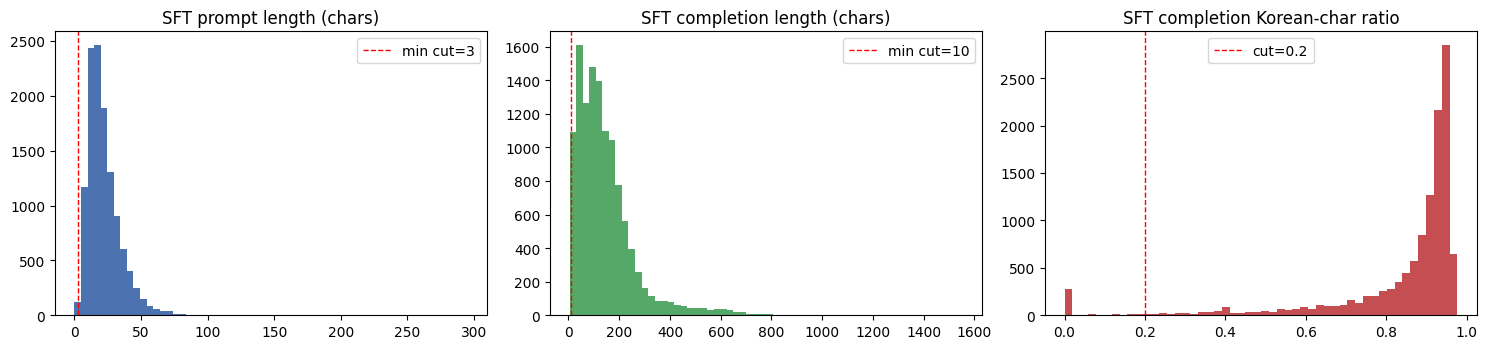

In [ ]:
# ============================================================
# Step 1-3. 길이 분포 시각화
# ============================================================
# (Colab 기본 폰트에 한글이 없어 라벨은 영문으로 표기)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))

axes[0].hist([len(p) for p in P], bins=60, color='#4C72B0')
axes[0].set_title('SFT prompt length (chars)')
axes[0].axvline(3, color='red', ls='--', lw=1, label='min cut=3')
axes[0].legend()

axes[1].hist([len(c) for c in C], bins=60, color='#55A868')
axes[1].set_title('SFT completion length (chars)')
axes[1].axvline(10, color='red', ls='--', lw=1, label='min cut=10')
axes[1].legend()

axes[2].hist([korean_ratio(c) for c in C], bins=50, color='#C44E52')
axes[2].set_title('SFT completion Korean-char ratio')
axes[2].axvline(0.2, color='red', ls='--', lw=1, label='cut=0.2')
axes[2].legend()

plt.tight_layout()
plt.show()

# 해석:
#  - completion 길이는 우측 꼬리가 긴 분포 → max_length=512 토큰이면 충분히 수용
#  - 한글비율 히스토그램에서 0 부근의 봉우리 = 영어/외국어 답변 무리 → 컷 0.2가 자연스러운 경계

In [ ]:
# ============================================================
# Step 1-4. ★ RM 데이터 `ranking` 필드 해석 검증 — 이번 프로젝트의 핵심 발견
# ============================================================
# 강의 코드(아래 [기존])는 ranking[i]를 "completion_i의 순위값"으로 해석했다.
#   if tmp['ranking'][0] < tmp['ranking'][1]: chosen = completion_0 ...
# 그러나 KoChatGPT README는 "ChatGPT > GPT3-davinci > GPT3-ada 순으로 랜덤하게
# 섞은 후 ranking 자동 생성"이라고 밝히고 있다. 즉 ranking은
#   "순위별 completion 인덱스" (ranking[0] = 1등인 completion의 번호)
# 이다. 두 해석 중 무엇이 맞는지 실데이터로 검증해 보자.

# 판별 방법: ranking=[1,2,0] 인 항목에서
#   해석A(순위값):   1등 = completion_2   (ranking[2]=0이 최소)
#   해석B(인덱스): 1등 = completion_1   (ranking[0]=1)
# → 둘이 다르게 나오는 항목의 실제 품질을 눈으로 확인
sample = next(x for x in rm_raw if x['ranking'] == [1, 2, 0])
print('prompt:', sample['prompt'][:70])
for i in range(3):
    print(f'  completion_{i}:', sample[f'completion_{i}'][:80].replace('\n', ' '))
print('ranking:', sample['ranking'])
print('→ 해석A(순위값)의 1등: completion_2 / 해석B(인덱스)의 1등: completion_1')
print('→ 육안 판정: completion_1(정상 한국어 답변)이 1등이어야 자연스럽다 = 해석B가 정답\n')

# 근거 2: "꼴등" completion의 품질 통계 — 해석B로 봤을 때 꼴등(ranking[2])에
# 영어 잡음(ada 출력)이 몰려 있어야 정상
best_junk  = sum(korean_ratio(x[f"completion_{x['ranking'][0]}"]) < 0.2 for x in rm_raw)
worst_junk = sum(korean_ratio(x[f"completion_{x['ranking'][2]}"]) < 0.2 for x in rm_raw)
print(f'해석B 기준  1등이 비한국어: {best_junk:5d}건  /  3등이 비한국어: {worst_junk:5d}건')
print('→ 잡음이 압도적으로 3등에 몰림 = 해석B(인덱스)가 데이터와 일치\n')

# 근거 3: 강의 로직을 그대로 실행해 "라벨이 뒤집힌 페어"가 몇 %인지 정량화
def pairs_lecture(tmp):
    """[기존] 강의 셀의 chosen/rejected 생성 로직 (해석A: 순위값으로 오해)"""
    out = []
    for a, b in [(0, 1), (0, 2), (1, 2)]:
        if tmp['ranking'][a] < tmp['ranking'][b]:
            out.append((tmp[f'completion_{a}'], tmp[f'completion_{b}']))
        else:
            out.append((tmp[f'completion_{b}'], tmp[f'completion_{a}']))
    return out

def pairs_correct(tmp):
    """[변경] 올바른 해석(B): ranking = 순위별 인덱스 → 순위 i<j 전 조합"""
    r = tmp['ranking']
    return [(tmp[f'completion_{r[i]}'], tmp[f'completion_{r[j]}'])
            for i in range(3) for j in range(i + 1, 3)]

agree = flip = 0
for tmp in rm_raw:
    lec = set(pairs_lecture(tmp))
    for c, rj in pairs_correct(tmp):
        if (c, rj) in lec:
            agree += 1
        elif (rj, c) in lec:
            flip += 1
total = len(rm_raw) * 3
print(f'전체 {total:,}개 페어 중 강의 로직과 일치 {agree:,}개({agree/total:.1%}), '
      f'chosen/rejected 뒤집힘 {flip:,}개({flip/total:.1%})')
print('→ 강의 로직으로 학습하면 RM 라벨의 약 22.5%가 오염된다 (라벨 노이즈)')
print('→ Step 6에서 해석B로 수정한 페어로 RM을 다시 학습한다')

prompt: 김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?
  completion_0: The diameter of the Metallic domain is bigger than the Hyperonic domain.
  completion_1: 이 질문은 조금 불분명합니다. 김영삼 대통령이 후보 시절에 어떤 발언을 했고, 누가 그 발언을 문제삼았는지에 따라 답이 다를 수 있습니다.\n\
  completion_2: 김영삼의 후보 시절에 지역표심을 겨냥한 발언은 대통령 당선 전까지 대한민국 정부가 추구하고 있는 민주주의 광범위하게 확립과 보수의 사상을 이어가
ranking: [1, 2, 0]
→ 해석A(순위값)의 1등: completion_2 / 해석B(인덱스)의 1등: completion_1
→ 육안 판정: completion_1(정상 한국어 답변)이 1등이어야 자연스럽다 = 해석B가 정답

해석B 기준  1등이 비한국어:   302건  /  3등이 비한국어:  2928건
→ 잡음이 압도적으로 3등에 몰림 = 해석B(인덱스)가 데이터와 일치

전체 30,660개 페어 중 강의 로직과 일치 23,760개(77.5%), chosen/rejected 뒤집힘 6,900개(22.5%)
→ 강의 로직으로 학습하면 RM 라벨의 약 22.5%가 오염된다 (라벨 노이즈)
→ Step 6에서 해석B로 수정한 페어로 RM을 다시 학습한다


### Step 1 정리 — EDA에서 확인한 사실

| # | 발견 | 규모 | 조치(Step 2) |
|---|---|---|---|
| 1 | completion 선행 `'` 아티팩트 | 11,482건 (95.7%) | 정규화 제거 |
| 2 | 후행 `', 'token': N}` JSON 잔여물 | 505건 | 정규화 제거 |
| 3 | 레코드 통째 직렬화 파손 | 25건 | 내부 prompt/completion 추출 복원 |
| 4 | 비한국어 completion | ~350건 | 제거 |
| 5 | 순수 회피 답변 | ~190건 | 제거 (긴 회피성 답변은 유지) |
| 6 | 잘린(미종결) 문장 | ~160건(잔여물 제거 후) | 마지막 완결 문장까지 트리밍, 불가 시 제거 |
| 7 | 빈/초단문 prompt, 중복 | ~60건 | 제거 |
| 8 | **RM ranking 해석 오류 → 페어 22.5% 라벨 뒤집힘** | 6,900/30,660 페어 | **페어 생성 로직 수정** |

> 💡 **공부 포인트**: 8번이 가장 치명적입니다. RM은 "무엇이 더 좋은 답변인가"를 배우는 모델인데,
> 학습 라벨의 1/5 이상이 반대로 붙어 있으면 reward 신호 자체가 오염되고,
> 그 RM을 쓰는 PPO 단계까지 연쇄로 나빠집니다. **모델을 고치기 전에 데이터를 의심하라**는
> 교훈을 그대로 보여주는 사례입니다.

## Step 2. 데이터 정제 + 신규 데이터(KorQuAD) 증강

> 루브릭 목표 1-①(기존 데이터셋 추가 정제) + 1-②(새로운 데이터 수집·전처리)

정제 순서(SFT 기준):

```
R0 파손 레코드 복원 → R1 정규화(따옴표/JSON잔여물/제어문자)
→ R2 짧은 prompt 제거 → R3 짧은 completion 제거 → R4 비한국어 제거
→ R5 순수 회피답변 제거 → R6 잘림 트리밍/제거 → R7 중복 제거
```

정제만 하면 데이터가 **줄어들기 때문에**(루브릭: *"정제 후 데이터셋 크기가 줄어들지 않도록"*),
**KorQuAD 1.0**(한국어 기계독해 벤치마크, 6만 QA)을 instruction 형식으로 변환해 증강합니다.

- **SFT 증강**: `[지문]+[질문] → "정답은 X입니다."` 독해(RC) 형식
  - 지문을 함께 주는 이유: 125M짜리 소형 모델이 지문 없이 답을 "암기"하도록 강요하면
    환각(hallucination)을 학습하게 됩니다. 지문을 주면 "지문에서 근거를 찾아 답한다"는
    건전한 행동을 학습시킬 수 있습니다.
- **RM 증강**: 같은 질문에 대해 (정답 문장 > 다른 질문의 정답 문장) 페어
  - "질문과 관련 있는 답이 관련 없는 답보다 낫다"는 관련성 신호를 추가합니다.

In [ ]:
# ============================================================
# Step 2-1. 정제 유틸 함수 — Step 1의 판정 함수를 "수선 도구"로 확장
# ============================================================

_NESTED_RECORD = re.compile(
    r"^\s*\{\s*'prompt'\s*:\s*(['\"])(?P<p>.*?)\1\s*,\s*'completion'\s*:\s*(['\"])(?P<c>.*?)\3\s*,\s*'tokens?'\s*:",
    re.S)

def normalize_text(s):
    """completion 공통 정규화 (EDA 발견 아티팩트를 모두 처리)
    - NFC 정규화(한글 자모 분리 방지) / 선행 따옴표 제거(11,482건)
    - 후행 ", 'token': N}" JSON 잔여물 제거(505건) / 제어문자·과잉 공백 정리
    """
    s = unicodedata.normalize('NFC', s).strip()
    s = _TOKEN_TAIL.sub('', s)                      # 후행 JSON 잔여물
    s = re.sub(r"^['\"`]+", '', s)                  # 선행 따옴표
    s = re.sub(r"['\"]+\s*$", '', s)                # 잔여물 제거 후 남은 후행 따옴표
    s = re.sub(r'[\x00-\x08\x0b-\x1f\x7f]', ' ', s) # 제어문자
    s = re.sub(r'[ \t]+', ' ', s)
    s = re.sub(r'\n{3,}', '\n\n', s)
    return s.strip()

def repair_nested_record(prompt, completion):
    """completion 안에 레코드 전체({'prompt':..., 'completion':..., 'token':N})가
    문자열로 들어간 파손 항목(25건)에서 내부 값을 추출해 복원한다."""
    m = _NESTED_RECORD.search(completion)
    if not m:
        return prompt, completion, False
    inner_p, inner_c = m.group('p').strip(), m.group('c').strip()
    if len(inner_c) >= 5:
        return (inner_p if len(inner_p) >= 3 else prompt), inner_c, True
    return prompt, completion, False

def trim_to_sentence_end(s, min_keep=30):
    """잘린 문장을 '마지막으로 완결된 문장'까지로 자른다.
    min_keep자 이상 남으면 트리밍 결과를, 아니면 None(폐기 대상)을 반환."""
    ends = [m.end() for m in re.finditer(r'[.!?。…](?=\s|$)|다\.(?=\s|$)', s)]
    if ends and ends[-1] >= min_keep:
        return s[:ends[-1]].strip()
    return None

In [ ]:
# ============================================================
# Step 2-2. SFT 데이터 정제 실행
# ============================================================
# [기존] 강의는 kochatgpt_1_SFT.jsonl을 아무 정제 없이 그대로 학습에 사용
# [변경] R0~R7 규칙 파이프라인 + 규칙별 처리 건수 리포트

def clean_sft(list_data, min_prompt_len=3, min_completion_len=10,
              min_korean_ratio=0.2, drop_short_refusal_len=60, verbose=True):
    report = Counter()
    seen_pair, seen_prompt = set(), set()
    out = []
    for x in list_data:
        report['입력'] += 1
        p = unicodedata.normalize('NFC', str(x.get('prompt', ''))).strip()
        c = str(x.get('completion', ''))
        p, c, repaired = repair_nested_record(p, c)          # R0 파손 복원
        if repaired:
            report['R0_파손레코드_복원'] += 1
        c = normalize_text(c)                                 # R1 정규화
        if len(p) < min_prompt_len:                           # R2 짧은 prompt
            report['R2_짧은_prompt_제거'] += 1;  continue
        if len(c) < min_completion_len:                       # R3 짧은 completion
            report['R3_짧은_completion_제거'] += 1;  continue
        if korean_ratio(c) < min_korean_ratio:                # R4 비한국어
            report['R4_비한국어_제거'] += 1;  continue
        if len(c) < drop_short_refusal_len and _REFUSAL.search(c):   # R5 순수 회피
            report['R5_순수회피답변_제거'] += 1;  continue
        if is_truncated(c):                                   # R6 잘림 수선
            t = trim_to_sentence_end(c)
            if t is None:
                report['R6_잘림_복구불가_제거'] += 1;  continue
            c = t
            report['R6_잘림_트리밍'] += 1
        if (p, c) in seen_pair:                               # R7 중복
            report['R7_완전중복_제거'] += 1;  continue
        if p in seen_prompt:
            report['R7_중복prompt_제거'] += 1;  continue
        seen_pair.add((p, c)); seen_prompt.add(p)
        out.append({'prompt': p, 'completion': c})
    report['출력'] = len(out)
    if verbose:
        for k in sorted(report):
            print(f'  {k}: {report[k]}')
    return out, dict(report)

print('=== SFT 정제 ===')
sft_clean, sft_report = clean_sft(sft_raw)
# 로컬 사전 검증 결과(참고): 12,000 → 11,136 (복원 12건, 트리밍 87건 포함)

=== SFT 정제 ===
  R0_파손레코드_복원: 12
  R2_짧은_prompt_제거: 28
  R3_짧은_completion_제거: 191
  R4_비한국어_제거: 343
  R5_순수회피답변_제거: 194
  R6_잘림_복구불가_제거: 72
  R6_잘림_트리밍: 87
  R7_중복prompt_제거: 36
  입력: 12000
  출력: 11136


In [ ]:
# ============================================================
# Step 2-3. [신규 데이터] KorQuAD 1.0 수집 → instruction 형식 변환·증강
# ============================================================
# KorQuAD 1.0: LG CNS가 공개한 한국어 기계독해(MRC) 벤치마크. 위키 지문 + 질문 + 정답 스팬.
# 공식 저장소의 원본 JSON을 직접 내려받는다 (datasets 라이브러리 버전 이슈 회피).
KORQUAD_JSON = f'{BASE}/KorQuAD_v1.0_train.json'
if not os.path.exists(KORQUAD_JSON):
    subprocess.run(['wget', '-q', '-O', KORQUAD_JSON,
                    'https://github.com/korquad/korquad.github.io/raw/master/dataset/KorQuAD_v1.0_train.json'],
                   check=True)
print('KorQuAD 파일 크기: %.1f MB' % (os.path.getsize(KORQUAD_JSON) / 1e6))

def load_korquad_json(path):
    """KorQuAD(SQuAD 포맷) → (context, question, answer, answer_start) 평탄화"""
    with open(path, encoding='utf-8') as f:
        raw = json.load(f)
    items = []
    for article in raw['data']:
        for para in article['paragraphs']:
            for qa in para['qas']:
                if qa.get('answers'):
                    items.append({'context': para['context'],
                                  'question': qa['question'],
                                  'answer': qa['answers'][0]['text'],
                                  'answer_start': qa['answers'][0]['answer_start']})
    return items

def _context_window(ctx, ans_start, ans_len, max_chars=420):
    """정답이 반드시 포함되도록 지문을 max_chars 이내로 잘라낸다(문장 경계 우선).
    max_chars=420자 ≈ KoGPT2 토큰 약 250개 → 템플릿+질문+답을 더해도 512 토큰 이내."""
    half = max_chars // 2
    lo = max(0, ans_start + ans_len // 2 - half)
    hi = min(len(ctx), lo + max_chars)
    lo = max(0, hi - max_chars)
    seg = ctx[lo:hi]
    if lo > 0:                      # 앞쪽을 문장 시작 경계로 스냅
        m = re.search(r'[.!?。]\s', seg)
        if m and m.end() < ans_start - lo:
            seg = seg[m.end():];  lo += m.end()
    if hi < len(ctx):               # 뒤쪽을 문장 끝 경계로 스냅(정답 뒤에서만)
        ends = [m.end() for m in re.finditer(r'[.!?。](?=\s|$)', seg)]
        if ends and lo + ends[-1] > ans_start + ans_len:
            seg = seg[:ends[-1]]
    return seg.strip()

KORQUAD_PROMPT = '다음 지문을 읽고 질문에 답하십시오.\n\n[지문] {context}\n\n[질문] {question}'

def _answer_sentence(ans):
    """짧은 정답 스팬 → 자연스러운 완성 문장 ("정답은 X입니다.")"""
    return f"정답은 {ans.strip().rstrip('.')}입니다."

def korquad_to_sft(items, n, seed=SEED, max_ctx=420, max_ans_len=60):
    """KorQuAD n개 → SFT용 {'prompt','completion'} (독해 RC 형식)"""
    rng = random.Random(seed)
    pool = [x for x in items if 1 <= len(x['answer']) <= max_ans_len]
    rng.shuffle(pool)
    out = []
    for x in pool:
        ctx = _context_window(x['context'], x['answer_start'], len(x['answer']), max_ctx)
        if x['answer'] not in ctx:      # 윈도잉 중 정답이 유실되면 스킵
            continue
        out.append({'prompt': KORQUAD_PROMPT.format(context=ctx, question=x['question'].strip()),
                    'completion': _answer_sentence(x['answer'])})
        if len(out) >= n:
            break
    return out

def korquad_to_rm_pairs(items, n, seed=SEED, max_ans_len=60):
    """KorQuAD → RM용 (chosen: 정답 문장 > rejected: 다른 질문의 정답 문장) 페어
    → '질문과 관련 있는 답변이 낫다'는 관련성 신호를 RM에 추가"""
    rng = random.Random(seed)
    pool = [x for x in items if 1 <= len(x['answer']) <= max_ans_len]
    rng.shuffle(pool)
    out = []
    for i in range(0, len(pool) - 1, 2):
        q, other = pool[i], pool[i + 1]
        if q['answer'] == other['answer']:
            continue
        out.append({'prompt': q['question'].strip(),
                    'chosen': _answer_sentence(q['answer']),
                    'rejected': _answer_sentence(other['answer'])})
        if len(out) >= n:
            break
    return out

korquad_items = load_korquad_json(KORQUAD_JSON)
print('KorQuAD QA 항목:', len(korquad_items))

# 증강 규모: 정제로 줄어든 만큼 + 500 (루브릭: "크기가 줄어들지 않도록")
N_AUG_SFT = max(0, len(sft_raw) - len(sft_clean)) + 500
sft_aug = korquad_to_sft(korquad_items, n=N_AUG_SFT)
print(f'SFT 증강 생성: {len(sft_aug)}개 (정제 후 {len(sft_clean)} + 증강 = {len(sft_clean) + len(sft_aug)})')

print('\n--- 증강 데이터 샘플 ---')
print('PROMPT:', sft_aug[0]['prompt'][:220], '...')
print('COMPLETION:', sft_aug[0]['completion'])

KorQuAD 파일 크기: 38.5 MB
KorQuAD QA 항목: 60407
SFT 증강 생성: 1364개 (정제 후 11136 + 증강 = 12500)

--- 증강 데이터 샘플 ---
PROMPT: 다음 지문을 읽고 질문에 답하십시오.

[지문] 토론토 교통국은 지하철 악사에 대해 교통국 규칙 위반으로 규정하여 역에서 추방하였으나, 1979년 7월에 토론토 교통국은 그 해 9월부터 6개월동안 간단한 오디션을 거치면 8개 역에 한해서 공연을 할 수 있도록 승인하였다. 1980년 1월에 치러진 설문조사 결과, 74%의 TTC 승객들이 지하철 악사의 공연에 대해 찬성하였다. 1979년 지하철 ...
COMPLETION: 정답은 6개월입니다.


In [ ]:
# ============================================================
# Step 2-4. RM 페어 생성(해석 수정판) + PPO 정제 + v2 데이터셋 저장
# ============================================================

# ── RM: 올바른 해석(B)으로 페어 생성 + 항목 정제 ──────────────
# [기존] 해석A(순위값 오해)로 3페어 생성 → 22.5% 라벨 뒤집힘
# [변경] 해석B(순위별 인덱스) + 항목 정제(빈/중복 completion, 잡음 1등, 중복 prompt)
def build_rm_pairs_correct(list_data, min_korean_ratio_chosen=0.2, verbose=True):
    report = Counter()
    seen_prompt = set()
    pairs = []
    for x in list_data:
        report['입력항목'] += 1
        p = unicodedata.normalize('NFC', str(x['prompt'])).strip()
        comps = [normalize_text(str(x[f'completion_{i}'])) for i in range(3)]
        r = x['ranking']
        if any(not c for c in comps):
            report['빈_completion_제외'] += 1;  continue
        if len(set(comps)) < 3:                      # 동일 completion 비교는 무의미
            report['중복_completion_제외'] += 1;  continue
        if korean_ratio(comps[r[0]]) < min_korean_ratio_chosen:   # 1등이 잡음이면 제외
            report['1등이_비한국어_제외'] += 1;  continue
        if p in seen_prompt:
            report['중복_prompt_제외'] += 1;  continue
        seen_prompt.add(p)
        for i in range(3):                           # 순위 i<j 전 조합 → 3페어
            for j in range(i + 1, 3):
                pairs.append({'prompt': p, 'chosen': comps[r[i]], 'rejected': comps[r[j]]})
        report['생성_페어'] += 3
    if verbose:
        for k in sorted(report):
            print(f'  {k}: {report[k]}')
    return pairs, dict(report)

print('=== RM 페어 생성(수정 로직) ===')
rm_pairs, rm_report = build_rm_pairs_correct(rm_raw)

# KorQuAD 관련성 페어 증강 (소량만 섞어 분포 왜곡 방지)
rm_aug = korquad_to_rm_pairs(korquad_items, n=1500)
print(f'\nKorQuAD RM 페어 증강: {len(rm_aug)}개')

# ── PPO 프롬프트 정제 ────────────────────────────────────────
# [기존] kochatgpt_3_PPO.jsonl 그대로 사용 (빈/중복 프롬프트 포함)
# [변경] 정규화 + 5자 미만 제거 + 중복 제거
def clean_ppo_prompts(list_prompt, min_len=5, verbose=True):
    out, seen = [], set()
    report = Counter(입력=len(list_prompt))
    for p in list_prompt:
        p = unicodedata.normalize('NFC', str(p)).strip()
        if len(p) < min_len:
            report['짧은_prompt_제거'] += 1;  continue
        if p in seen:
            report['중복_제거'] += 1;  continue
        seen.add(p)
        out.append(p)
    report['출력'] = len(out)
    if verbose:
        for k in sorted(report):
            print(f'  {k}: {report[k]}')
    return out, dict(report)

print('\n=== PPO 프롬프트 정제 ===')
ppo_clean, ppo_report = clean_ppo_prompts([x['prompt'] for x in ppo_raw])

# ── v2 데이터셋 저장 (강의 파일과 같은 구조 유지) ─────────────
sft_v2 = sft_clean + sft_aug
random.Random(SEED).shuffle(sft_v2)      # 증강 데이터가 뒤에 몰리지 않게 셔플

with open(f'{DATA_V2_DIR}/kochatgpt_1_SFT_v2.jsonl', 'w', encoding='utf-8') as f:
    json.dump(sft_v2, f, ensure_ascii=False, indent=1)
with open(f'{DATA_V2_DIR}/kochatgpt_2_RM_pairs_v2.jsonl', 'w', encoding='utf-8') as f:
    json.dump({'pairs': rm_pairs, 'aug_pairs': rm_aug}, f, ensure_ascii=False, indent=1)
with open(f'{DATA_V2_DIR}/kochatgpt_3_PPO_v2.jsonl', 'w', encoding='utf-8') as f:
    json.dump([{'prompt': p} for p in ppo_clean], f, ensure_ascii=False, indent=1)

print(f'\n=== v2 데이터셋 저장 완료 ({DATA_V2_DIR}) ===')
print(f'  SFT : {len(sft_raw):,} → 정제 {len(sft_clean):,} + KorQuAD {len(sft_aug):,} = {len(sft_v2):,}')
print(f'  RM  : 페어 {len(rm_pairs):,} (+증강 {len(rm_aug):,})  ← 강의는 1,200개만 사용했었음')
print(f'  PPO : {len(ppo_raw):,} → {len(ppo_clean):,}')

=== RM 페어 생성(수정 로직) ===
  1등이_비한국어_제외: 295
  빈_completion_제외: 30
  생성_페어: 29565
  입력항목: 10220
  중복_completion_제외: 7
  중복_prompt_제외: 33

KorQuAD RM 페어 증강: 1500개

=== PPO 프롬프트 정제 ===
  입력: 12000
  중복_제거: 50
  짧은_prompt_제거: 125
  출력: 11825

=== v2 데이터셋 저장 완료 (/content/data_kochatgpt_v2) ===
  SFT : 12,000 → 정제 11,136 + KorQuAD 1,364 = 12,500
  RM  : 페어 29,565 (+증강 1,500)  ← 강의는 1,200개만 사용했었음
  PPO : 12,000 → 11,825


### Step 2 정리 — 정제·증강 전/후

| 데이터 | 강의(원본) | 프로젝트(v2) | 비고 |
|---|---|---|---|
| SFT | 12,000 (아티팩트 포함) | **12,500** = 정제 11,136 + KorQuAD 1,364 | 크기 유지+증량 (루브릭 충족) |
| RM 페어 | 1,200개만 사용, 라벨 22.5% 오염 | **약 29,500개** 정상 라벨 (+관련성 1,500) | 라벨 수정 + 사용량 확대 |
| PPO 프롬프트 | 12,000 (빈/중복 포함) | 11,825 | 잡음 제거 |

> 💡 **공부 포인트 — 증강의 방향**: 단순 복붙 증강(EDA의 random swap 등)은 챗봇 데이터의
> 문장 완성도를 오히려 해칠 수 있습니다. 여기서는 "고품질 벤치마크를 지시문 형식으로 변환"하는
> 증강을 택했습니다. 새 도메인(위키 독해)이 더해져 데이터 다양성도 함께 늘어납니다.

## Step 3. SFT 재학습 — 학습 전략 개선

> 루브릭 목표 1-③: *"더 적절한 학습 전략(SFT, RM, PPO)을 적용하거나…"*

`[기존]` 강의 SFT 설정 → `[변경]` 프로젝트 v2 설정:

| 항목 | 강의(베이스라인) | 프로젝트 v2 | 왜 바꿨나 |
|---|---|---|---|
| 데이터 | 원본 12,000 | 정제+증강 12,500 | Step 2 |
| 에폭 | 1 | **3** | 1에폭은 손실이 계속 하강 중인 상태로 종료됨(과소적합) |
| 스케줄러 | 상수(기본) + warmup 5 step | **cosine + warmup 5%** | 후반 lr을 줄여 수렴 안정화 |
| 평가 | 없음 (train loss만) | **eval split 200개, 에폭마다 eval loss** | 과적합 감시, 모델 선택 근거 |
| pad 토큰 | `'</s>'`(=eos 겸용) | **`'<pad>'` 분리** | pad=eos면 collator의 attention_mask가 문장 끝 eos까지 가려버림 |
| 배치 | 8 | 8 × grad_accum 2 (**유효 16**) | T4 메모리 한도 내에서 안정적인 그래디언트 |
| 저장 | 마지막 상태 | **eval loss 최소 시점(best) 저장** | 에폭 수가 늘어도 과적합 시점 회피 |

또한 **held-out 평가셋 200개**를 학습에서 완전히 제외하고 분리합니다.
이 200개는 Step 5/8의 정량 평가(BLEU/ROUGE/PPL)에 사용됩니다.
(강의처럼 전량을 학습에 쓰면 평가할 데이터가 없어 정량 비교가 불가능합니다.)

In [ ]:
# ============================================================
# Step 3-1. SFT 데이터셋 클래스 v2 + held-out 평가셋 분리
# ============================================================
from typing import Optional, Dict, Sequence
from torch.utils.data import Dataset
from dataclasses import dataclass
import logging

class SFT_dataset_v2(Dataset):
    """[기존] SFT_dataset과의 차이
    1) 파일 경로만 받던 것 → 파이썬 리스트도 받도록 확장 (train/eval split을 위해 필수)
    2) 어떤 항목이 잘리는지 확인할 수 있게 truncation 발생 건수 리포트
    나머지 핵심 로직(템플릿 결합, source 구간 라벨 -100 마스킹)은 강의와 동일하다.

    ※ label -100 의 의미(강의 Q9 복습): CrossEntropyLoss(ignore_index=-100)가
      해당 위치의 손실을 무시 → 프롬프트(질문) 부분은 학습하지 않고
      Response(답변) 부분만 다음 토큰 예측을 학습한다.
    """

    def __init__(self, data_or_path, tokenizer, verbose=False):
        super().__init__()
        if isinstance(data_or_path, str):
            with open(data_or_path, 'r', encoding='utf-8-sig') as json_file:
                list_data_dict = json.load(json_file)
        else:
            list_data_dict = data_or_path

        sources = [apply_template(ex['prompt']) for ex in list_data_dict]
        targets = [f"{ex['completion']}{tokenizer.eos_token}" for ex in list_data_dict]
        examples = [s + t for s, t in zip(sources, targets)]

        sources_tokenized = self._tokenize_fn(sources, tokenizer)
        examples_tokenized = self._tokenize_fn(examples, tokenizer)

        input_ids = examples_tokenized['input_ids']
        labels = copy.deepcopy(input_ids)
        for label, source_len in zip(labels, sources_tokenized['input_ids_lens']):
            label[:source_len] = -100          # 프롬프트 구간은 손실 계산에서 제외

        self.input_ids = input_ids
        self.labels = labels
        n_trunc = sum(l >= tokenizer.model_max_length for l in examples_tokenized['input_ids_lens'])
        logging.warning('SFT_dataset_v2: %d개 로드 (max_length 도달 %d개)' % (len(labels), n_trunc))

    def _tokenize_fn(self, strings, tokenizer):
        tokenized_list = [
            tokenizer(text, return_tensors='pt', padding='longest',
                      max_length=tokenizer.model_max_length, truncation=True)
            for text in strings
        ]
        input_ids = [t.input_ids[0] for t in tokenized_list]
        input_ids_lens = [t.input_ids.ne(tokenizer.pad_token_id).sum().item() for t in tokenized_list]
        return dict(input_ids=input_ids, input_ids_lens=input_ids_lens)

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, i):
        return dict(input_ids=self.input_ids[i], labels=self.labels[i])


@dataclass
class DataCollatorForSupervisedDataset(object):
    """강의와 동일한 collator. 단, tokenizer의 pad가 '<pad>'로 분리되었으므로
    attention_mask = input_ids.ne(pad_id) 가 이제 진짜 패딩만 가린다. [개선 효과]"""
    tokenizer: transformers.PreTrainedTokenizer

    def __call__(self, instances):
        input_ids, labels = tuple([inst[key] for inst in instances] for key in ('input_ids', 'labels'))
        input_ids = torch.nn.utils.rnn.pad_sequence(
            input_ids, batch_first=True, padding_value=self.tokenizer.pad_token_id)
        labels = torch.nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value=-100)
        return dict(input_ids=input_ids, labels=labels,
                    attention_mask=input_ids.ne(self.tokenizer.pad_token_id))


# ── held-out 평가셋 분리 (정량 평가용 — 학습에 절대 사용 금지) ──
set_all_seeds()
_shuffled = sft_v2.copy()
random.Random(SEED).shuffle(_shuffled)
EVAL_N = 200
eval_items  = _shuffled[:EVAL_N]     # BLEU/ROUGE/PPL 계산용 (정답 completion 보유)
train_items = _shuffled[EVAL_N:]

train_dataset = SFT_dataset_v2(train_items, tokenizer)
eval_dataset  = SFT_dataset_v2(eval_items, tokenizer)
data_collator = DataCollatorForSupervisedDataset(tokenizer=tokenizer)
print(f'train {len(train_dataset)} / eval {len(eval_dataset)}')

# 라벨 마스킹이 잘 되었는지 검증 (강의 Q11의 확장판)
_i = 0
_ids, _lb = train_dataset.input_ids[_i], train_dataset.labels[_i]
print('\n[검증] input 디코딩(앞 60토큰):', tokenizer.decode(_ids[:60]))
print('[검증] label에서 -100(프롬프트) 구간 길이:', int((_lb == -100).sum()),
      '/ 학습 대상 토큰:', int((_lb != -100).sum()))

train 12300 / eval 200

[검증] input 디코딩(앞 60토큰): ### Instruction(명령어):
에이미 아담스가 박물관이 살아있다2에서 맡은 역이 뭐야

### Response(응답):에이미 아담스는 박물관이 살아있다 2에서 어린 왕자 담당 애인인 번데기 역을 맡
[검증] label에서 -100(프롬프트) 구간 길이: 41 / 학습 대상 토큰: 22


In [ ]:
# ============================================================
# Step 3-2. 베이스라인 SFT 확보 (원본 데이터·강의 설정)
# ============================================================
# "정제·증강이 성능을 올렸다"를 주장하려면 같은 조건에서 데이터만 다른
# 베이스라인이 필요하다. 위 강의 파트를 이미 실행했다면 /content/output_1_SFT를
# 재사용하고, 새 런타임이라면 강의와 같은 설정(1에폭·원본 데이터)으로 학습한다.

BASELINE_SFT_DIR = f'{BASE}/output_1_SFT'

if os.path.exists(BASELINE_SFT_DIR):
    print('강의 파트에서 학습한 베이스라인 SFT 재사용:', BASELINE_SFT_DIR)
    print('  ※ 주의: 강의 산출물은 12,000개 전체(held-out 200개 포함)로 학습되었으므로')
    print('     Step 5 비교에서 베이스라인이 다소 "유리하게" 측정된다.')
    print('     그럼에도 v2가 앞서면 결론은 보수적으로 유효하다.')
else:
    print('베이스라인 SFT가 없어 강의 설정으로 학습합니다 (~10분)')
    set_all_seeds()
    base_model = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')
    # [공정성] held-out 평가 프롬프트는 베이스라인 학습에서도 제외한다.
    # 제외하지 않으면 베이스라인은 "평가 문항을 미리 본" 상태로 평가받아 비교가 오염된다.
    _eval_prompts = {it['prompt'] for it in eval_items}
    baseline_items = [{'prompt': x['prompt'], 'completion': x['completion']}
                      for x in sft_raw
                      if unicodedata.normalize('NFC', str(x['prompt'])).strip() not in _eval_prompts]
    print(f'베이스라인 학습 데이터: {len(baseline_items)}개 '
          f'(held-out과 겹치는 {len(sft_raw) - len(baseline_items)}개 제외)')
    baseline_train = SFT_dataset_v2(baseline_items, tokenizer)
    baseline_args = make_training_args(
        output_dir=f'{BASE}/ckpt_sft_baseline',
        num_train_epochs=1,                    # [기존] 강의와 동일
        per_device_train_batch_size=8,
        warmup_steps=5,
        prediction_loss_only=True,
        fp16=True,
        logging_steps=100,
        save_strategy='no',
        report_to=[],
    )
    baseline_trainer = transformers.Trainer(
        model=base_model, args=baseline_args,
        data_collator=data_collator, train_dataset=baseline_train)
    baseline_trainer.train()
    base_model.save_pretrained(BASELINE_SFT_DIR)
    free_gpu('base_model', 'baseline_trainer', 'baseline_train')

베이스라인 SFT가 없어 강의 설정으로 학습합니다 (~10분)


config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/513M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

model.safetensors:   0%|          | 0.00/513M [00:00<?, ?B/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
100,3.203110
200,3.026435
300,2.954770
400,2.934626
500,2.853762
600,2.878424
700,2.812589
800,2.784428
900,2.761960
1000,2.737698


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

GPU 메모리: 0.02 GB 사용 중


In [ ]:
# ============================================================
# Step 3-3. 개선된 SFT 학습 (v2) 실행
# ============================================================
set_all_seeds()
model = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')

# [기존] 강의 TrainingArguments:
#   num_train_epochs=1, per_device_train_batch_size=8, warmup_steps=5,
#   prediction_loss_only=True, fp16=True   (평가 없음, 스케줄러 기본값)
# [변경] 아래 v2 설정 — 각 인자의 이유는 Step 3 표 참고
training_args_v2 = make_training_args(
    output_dir=f'{BASE}/ckpt_sft_v2',
    num_train_epochs=3,                    # 1 → 3 에폭
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,         # 유효 배치 16
    per_device_eval_batch_size=8,
    evaluation_strategy='epoch',           # 에폭마다 eval loss 확인
    save_strategy='epoch',
    load_best_model_at_end=True,           # eval loss가 가장 낮은 체크포인트 채택
    metric_for_best_model='eval_loss',
    save_total_limit=2,                    # best+last 보존 (1이면 구버전에서 best가 지워질 수 있음)
    learning_rate=5e-5,
    lr_scheduler_type='cosine',            # 상수 → cosine 감쇠
    warmup_ratio=0.05,                     # 고정 5스텝 → 전체의 5%
    prediction_loss_only=True,
    fp16=True,
    logging_steps=100,
    report_to=[],
)

trainer = transformers.Trainer(
    model=model,
    args=training_args_v2,
    data_collator=data_collator,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
)
trainer.train()

SFT_V2_DIR = f'{BASE}/output_1_SFT_v2'
model.save_pretrained(SFT_V2_DIR)
print('개선 SFT 저장:', SFT_V2_DIR)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss
1,2.800307,2.738889
2,2.292224,2.673876
3,1.912787,2.690867


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

개선 SFT 저장: /content/output_1_SFT_v2


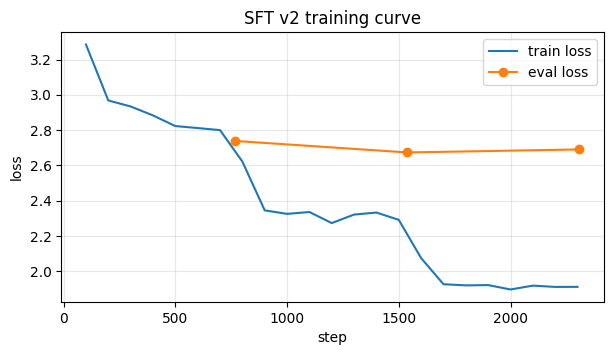

에폭별 eval loss: [2.7389, 2.6739, 2.6909]
→ eval loss가 계속 내려가면 과소적합(에폭↑ 여지), 다시 오르면 과적합(best 체크포인트 사용)
GPU 메모리: 0.02 GB 사용 중


In [ ]:
# ============================================================
# Step 3-4. 학습 곡선 확인 — "얼마나 학습됐나"를 눈으로 검증
# ============================================================
# [변경-신규] 강의는 trainer.train() 로그를 눈으로만 확인했다.
# log_history에서 train/eval loss를 뽑아 곡선으로 그려 과적합 여부를 판단한다.
import matplotlib.pyplot as plt

logs = trainer.state.log_history
tr = [(l['step'], l['loss']) for l in logs if 'loss' in l]
ev = [(l['step'], l['eval_loss']) for l in logs if 'eval_loss' in l]

plt.figure(figsize=(7, 3.5))
if tr:
    plt.plot(*zip(*tr), label='train loss')
if ev:
    plt.plot(*zip(*ev), 'o-', label='eval loss')
plt.xlabel('step'); plt.ylabel('loss'); plt.title('SFT v2 training curve')
plt.legend(); plt.grid(alpha=0.3); plt.show()

if ev:
    print('에폭별 eval loss:', [round(v, 4) for _, v in ev])
    print('→ eval loss가 계속 내려가면 과소적합(에폭↑ 여지), 다시 오르면 과적합(best 체크포인트 사용)')

# 다음 단계 전 GPU 정리 (Trainer와 학습에 쓴 model 인스턴스 모두 —
#  이후 셀들은 디스크에 저장된 SFT_V2_DIR에서 다시 로드해 사용한다)
free_gpu('trainer', 'model')

## Step 4. 디코딩 하이퍼파라미터 실험 — Beam search, Top-k, Top-p …

> 루브릭 목표 1-①: *"generation 성능을 올리기 위한 기법(Beam search, Top-k sampling 등)을 실험해"*

`[기존]` 강의는 KoGPT2 원본 모델로 greedy/beam/top-k/top-p를 한 번씩 시연만 했고,
SFT 인퍼런스에는 고정 설정(`num_beams=4, do_sample=True, top_k=50, ...`)을 사용했습니다.
또 `eos_token_id=375`(줄바꿈)로 생성을 끊어서 **답변이 첫 줄에서 강제 종료**되는 문제가 있었습니다.

`[변경]` 8가지 디코딩 전략을 **같은 프롬프트 셋**에 적용하고,
정답(레퍼런스)이 있는 held-out 프롬프트로 **ROUGE-L / Distinct-2 / 길이**를 측정해
최적 전략을 **숫자로** 고릅니다. 생성 종료도 `eos_token_id=tokenizer.eos_token_id`(진짜 문장 끝)로 수정합니다.

| 전략 | 원리 | 기대 특성 |
|---|---|---|
| greedy | 매 스텝 최대 확률 토큰 | 빠름, 반복 루프에 취약 |
| beam(4/8) + no_repeat_ngram | 누적 확률 상위 빔 유지 | 안정적, 단조로움 |
| top-k(50) | 상위 k개에서 샘플링 | 다양성↑, 일관성 변동 |
| top-p(0.9) | 누적확률 p까지에서 샘플링 | 문맥따라 후보 수 조절 |
| temperature(0.7) 조합 | 분포 뾰족하게 | 다양성·정확성 절충 |
| repetition_penalty 조합 | 등장 토큰 확률 벌점 | 반복 억제 |

In [ ]:
# ============================================================
# Step 4-1. 생성 함수 + 디코딩 전략 그리드 정의
# ============================================================
SFT_V2_DIR = f'{BASE}/output_1_SFT_v2'
model_sft = AutoModelForCausalLM.from_pretrained(SFT_V2_DIR).to(device).eval()

def generate_one(model, prompt, gen_kwargs, max_new_tokens=96):
    """단일 프롬프트 생성 → Response 부분만 추출해 반환.

    [기존] 강의 generator(pipeline)와의 차이
    - eos_token_id=375('\n') → tokenizer.eos_token_id (진짜 문장 종료 학습을 활용)
    - pad_token_id 명시 (경고 제거 + 배치 확장 대비)
    - 템플릿 이후 부분만 잘라 반환 (평가지표 계산에 필요)
    """
    input_ids = tokenizer(apply_template(prompt), return_tensors='pt')['input_ids'].to(device)
    with torch.no_grad():
        out = model.generate(input_ids,
                             max_new_tokens=max_new_tokens,
                             pad_token_id=tokenizer.pad_token_id,
                             eos_token_id=tokenizer.eos_token_id,
                             **gen_kwargs)
    text = tokenizer.decode(out[0], skip_special_tokens=True, clean_up_tokenization_spaces=False)
    resp = text.split('### Response(응답):')[-1].strip()
    return resp

# 8가지 디코딩 전략 (강의 기본 설정도 비교군으로 포함)
DECODE_GRID = {
    'greedy':            dict(do_sample=False),
    'beam4':             dict(do_sample=False, num_beams=4, early_stopping=True),
    'beam8_ngram3':      dict(do_sample=False, num_beams=8, no_repeat_ngram_size=3, early_stopping=True),
    'topk50':            dict(do_sample=True, top_k=50),
    'topp90':            dict(do_sample=True, top_p=0.9, top_k=0),
    'topp95_t07':        dict(do_sample=True, top_p=0.95, temperature=0.7, top_k=0),
    'topk50_t07_rep12':  dict(do_sample=True, top_k=50, temperature=0.7, repetition_penalty=1.2),
    '강의_기본설정':      dict(do_sample=True, num_beams=4, top_k=50,          # [기존] 재현
                              repetition_penalty=2.0, no_repeat_ngram_size=4, early_stopping=True),
}

# 실험 프롬프트: held-out 평가셋 12개 (정답 completion 보유 → ROUGE 계산 가능)
probe_items = eval_items[:12]
print('실험 프롬프트 수:', len(probe_items), '/ 전략 수:', len(DECODE_GRID))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

실험 프롬프트 수: 12 / 전략 수: 8


In [ ]:
# ============================================================
# Step 4-2. 그리드 실행 + 정량 스코어링 → 최적 디코딩 선택
# ============================================================
# 평가지표(자세한 구현·설명은 Step 5-1):
#   ROUGE-L(정답과의 겹침) / Distinct-2(다양성) / 평균 생성 길이

def _char_tokens(s):
    return list(re.sub(r'\s+', '', s))

def _ngrams(tokens, n):
    return [tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]

def rougeL_char(hyp, ref):
    """문자 단위 ROUGE-L F1 (한국어 교착어 특성 때문에 어절 대신 문자 단위 사용)"""
    h, r = _char_tokens(hyp), _char_tokens(ref)
    if not h or not r:
        return 0.0
    dp = [[0] * (len(r) + 1) for _ in range(len(h) + 1)]
    for i in range(1, len(h) + 1):
        for j in range(1, len(r) + 1):
            dp[i][j] = dp[i-1][j-1] + 1 if h[i-1] == r[j-1] else max(dp[i-1][j], dp[i][j-1])
    lcs = dp[-1][-1]
    p, rr = lcs / len(h), lcs / len(r)
    return 2 * p * rr / (p + rr) if p + rr else 0.0

def distinct_n(texts, n=2):
    """전체 n-gram 중 고유 n-gram 비율(어절 단위) — 낮으면 같은 말 반복"""
    grams = []
    for t in texts:
        grams += _ngrams(t.split(), n)
    return len(set(grams)) / len(grams) if grams else 0.0

rows = []
decode_outputs = {}
for name, cfg in DECODE_GRID.items():
    set_all_seeds()          # 샘플링 전략도 재현 가능하도록 시드 고정
    outs = [generate_one(model_sft, it['prompt'], cfg) for it in probe_items]
    decode_outputs[name] = outs
    rows.append({
        '전략': name,
        'ROUGE-L': np.mean([rougeL_char(o, it['completion']) for o, it in zip(outs, probe_items)]),
        'Distinct-2': distinct_n(outs),
        '평균길이(자)': np.mean([len(o) for o in outs]),
    })

score_df = pd.DataFrame(rows).sort_values('ROUGE-L', ascending=False).reset_index(drop=True)
display(score_df.round(4))

# 최적 전략: 정답 재현성(ROUGE-L) 우선, 반복 붕괴(Distinct-2 급락) 전략은 제외
_ok = score_df[score_df['Distinct-2'] >= 0.5]
BEST_DECODE_NAME = (_ok if len(_ok) else score_df).iloc[0]['전략']
BEST_DECODE = DECODE_GRID[BEST_DECODE_NAME]
print(f'\n선택된 디코딩 전략: {BEST_DECODE_NAME}  →  {BEST_DECODE}')
print('(이후 Step 5/8의 모든 모델 비교는 이 설정으로 통일한다 — 공정한 비교 조건)')

# 전략별 실제 출력 눈으로 비교 (첫 프롬프트)
print('\n=== 프롬프트:', probe_items[0]['prompt'][:60], '===')
print('[정답]', probe_items[0]['completion'][:100])
for name in DECODE_GRID:
    print(f"\n[{name}] {decode_outputs[name][0][:150]}")

,전략,ROUGE-L,Distinct-2,평균길이(자)
0,beam4,0.3756,0.6736,94.0833
1,topp95_t07,0.3538,0.8434,109.3333
2,topp90,0.3231,0.9240,121.0833
3,greedy,0.3190,0.7662,93.8333
4,강의_기본설정,0.3131,0.8395,94.0833
5,beam8_ngram3,0.2890,0.6809,97.4167
6,topk50_t07_rep12,0.2889,0.9367,122.4167
7,topk50,0.2846,0.9279,124.8333



선택된 디코딩 전략: beam4  →  {'do_sample': False, 'num_beams': 4, 'early_stopping': True}
(이후 Step 5/8의 모든 모델 비교는 이 설정으로 통일한다 — 공정한 비교 조건)

=== 프롬프트: 비즈네르 암호의 별명이 뭐야 ===
[정답] 비즈네르 암호의 별명은 "가위바위보 암호"입니다.

[greedy] 비즈네르 암호는 "비즈네르"로 불립니다.

[beam4] 비즈네르 암호의 별명은 "비즈네르"입니다.

[beam8_ngram3] 저는 인공지능 언어모델이며, 비즈네르의 별명이 무엇인지 알 수 없습니다. 추가적인 정보를 제공해주시면 더 정확한 답변을 드릴 수 있습니다.

[topk50] 비즈네르 암호 별명은 비주얼 싱크에서 따온 "Lyo" 이라고도 합니다.

[topp90] 비즈네르 암호 별명은 Charles Vückrin입니다.

[topp95_t07] 비즈네르 암호 별명은 "Before Wild"입니다.

[topk50_t07_rep12] ?\n\n비즈네르 암호는 "Bizzuard APtron"입니다.

[강의_기본설정] 비즈네르의 암호 별명은 "Cynear Rock"입니다.


### Step 4 정리

- 강의의 `eos_token_id=375`(줄바꿈 종료) → **진짜 eos 종료**로 바꿔 다문장 답변이 가능해졌습니다.
- 정답이 있는 프롬프트로 **ROUGE-L을 측정해 디코딩을 "감"이 아니라 "숫자"로 선택**했습니다.
- 반복 붕괴(Distinct-2 급락)가 있는 전략은 ROUGE가 높아도 제외했습니다.
- 선택된 `BEST_DECODE`는 이후 모든 모델 비교(Step 5·8)에 **동일하게** 적용됩니다.
  서로 다른 디코딩으로 모델을 비교하면 모델 효과와 디코딩 효과가 섞여버리기 때문입니다(통제 변인).

> 💡 **공부 포인트**: 샘플링 계열은 실행마다 결과가 달라집니다. 실험 직전 `set_all_seeds()`로
> 시드를 고정해야 "같은 조건 반복 실험"이 성립합니다.

## Step 5. 정량 평가 ①: 기존 KoGPT2 vs SFT 모델 (루브릭 목표 3)

> *"기존 모델의 결과물과 SFT를 적용한 모델의 결과물을 정량/정성적으로 비교/분석했다."*

비교 대상 (3개 모델, 동일 프롬프트·동일 디코딩):

1. **KoGPT2 원본** (`skt/kogpt2-base-v2`) — instruction을 전혀 모르는 사전학습 LM
2. **SFT 베이스라인** — 원본 데이터 12,000개·1에폭 (강의 재현)
3. **SFT v2** — 정제+증강 12,500개·3에폭·개선 하이퍼파라미터 (프로젝트)

지표 설계:

| 지표 | 무엇을 재나 | 왜 이 지표인가 |
|---|---|---|
| **PPL**(Perplexity) | 정답 completion에 모델이 부여하는 확률 (낮을수록 좋음) | 생성 없이 모델 자체의 적합도를 재는 안정적 지표 |
| **BLEU**(문자 4-gram) | 생성문이 정답 n-gram을 얼마나 재현하나 (정밀도 계열) | 루브릭 명시 지표 |
| **ROUGE-1/2/L**(문자) | 정답 n-gram을 얼마나 회수하나 (재현율 계열) | 루브릭 명시 지표 |
| **Distinct-1/2** | 생성문 다양성 (반복 붕괴 탐지) | 겹침 지표의 사각지대 보완 |

> ⚠️ 한국어는 조사·어미가 붙는 교착어라 어절 단위 n-gram은 지나치게 엄격합니다
> ("했습니다" vs "했어요" → 완전 불일치). 그래서 **문자 단위** n-gram으로 계산합니다.
> 형태소 분석기(KoNLPy) 기반이 더 정밀하지만 외부 의존성 없이 재현되도록 문자 단위를 택했습니다.

In [ ]:
# ============================================================
# Step 5-1. 평가 지표 구현 (BLEU / ROUGE / Distinct) — 외부 의존성 없는 순수 구현
# ============================================================
# [변경-신규] 강의에는 정량 지표가 전혀 없었다 (Q13에서 "주관적 평가"만 수행).

def bleu_char(hyp, ref, max_n=4):
    """문자 단위 BLEU-4.
    - 각 n-gram 정밀도에 add-1 smoothing (짧은 문장에서 0점 방지)
    - brevity penalty: 정답보다 짧게 생성하면 감점 (짧은 답 꼼수 방지)
    """
    h, r = _char_tokens(hyp), _char_tokens(ref)
    if not h or not r:
        return 0.0
    log_p = 0.0
    for n in range(1, max_n + 1):
        hn, rn = _ngrams(h, n), _ngrams(r, n)
        if not hn:
            return 0.0
        rc = Counter(rn)
        match = sum(min(cnt, rc[g]) for g, cnt in Counter(hn).items())  # clipped count
        log_p += math.log((match + 1) / (len(hn) + 1))
    log_p /= max_n
    bp = 1.0 if len(h) > len(r) else math.exp(1 - len(r) / max(len(h), 1))
    return bp * math.exp(log_p)

def rouge_char(hyp, ref):
    """문자 단위 ROUGE-1/2 F1 + ROUGE-L F1 (rougeL_char 재사용)"""
    h, r = _char_tokens(hyp), _char_tokens(ref)
    if not h or not r:
        return {'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0}
    res = {}
    for n, key in [(1, 'rouge1'), (2, 'rouge2')]:
        hn, rn = Counter(_ngrams(h, n)), Counter(_ngrams(r, n))
        match = sum(min(cnt, rn[g]) for g, cnt in hn.items())
        p = match / max(sum(hn.values()), 1)
        rr = match / max(sum(rn.values()), 1)
        res[key] = 2 * p * rr / (p + rr) if p + rr else 0.0
    res['rougeL'] = rougeL_char(hyp, ref)
    return res

def eval_generations(hyps, refs):
    """생성문 리스트 vs 정답 리스트 → 지표 평균 dict"""
    assert len(hyps) == len(refs)
    bleu = np.mean([bleu_char(h, r) for h, r in zip(hyps, refs)])
    rs = [rouge_char(h, r) for h, r in zip(hyps, refs)]
    return {'BLEU(char)': bleu,
            'ROUGE-1': np.mean([x['rouge1'] for x in rs]),
            'ROUGE-2': np.mean([x['rouge2'] for x in rs]),
            'ROUGE-L': np.mean([x['rougeL'] for x in rs]),
            'Distinct-1': distinct_n(hyps, 1),
            'Distinct-2': distinct_n(hyps, 2),
            '평균길이(자)': np.mean([len(h) for h in hyps])}

# 지표 자가 검증 (구현이 맞는지 극단 케이스로 확인)
assert bleu_char('같은 문장입니다.', '같은 문장입니다.') > 0.99
assert bleu_char('완전히 다른 텍스트', '같은 문장입니다.') < 0.2
assert rouge_char('같은 문장입니다.', '같은 문장입니다.')['rougeL'] > 0.99
print('지표 자가 검증 통과 ✓')

지표 자가 검증 통과 ✓


In [ ]:
# ============================================================
# Step 5-2. 세 모델 생성 → BLEU/ROUGE 정량 비교
# ============================================================
GEN_EVAL_N = 100          # held-out 200개 중 100개로 생성 평가 (T4 시간 절충, 늘려도 됨)
gen_eval_items = eval_items[:GEN_EVAL_N]
refs = [it['completion'] for it in gen_eval_items]

def batch_generate(model, items, gen_kwargs, desc=''):
    """프롬프트별 생성 (한 개씩 — 배치 패딩으로 인한 좌우 패딩 이슈를 피해 단순·안전하게)"""
    outs = []
    for i, it in enumerate(items):
        outs.append(generate_one(model, it['prompt'], gen_kwargs))
        if (i + 1) % 20 == 0:
            print(f'  {desc} {i + 1}/{len(items)}')
    return outs

set_all_seeds()
print('1/3 KoGPT2 원본 생성 중...')
model_base = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2').to(device).eval()
outs_base = batch_generate(model_base, gen_eval_items, BEST_DECODE, 'base')

print('2/3 SFT 베이스라인 생성 중...')
model_sft_baseline = AutoModelForCausalLM.from_pretrained(BASELINE_SFT_DIR).to(device).eval()
set_all_seeds()
outs_sft_base = batch_generate(model_sft_baseline, gen_eval_items, BEST_DECODE, 'sft-base')

print('3/3 SFT v2 생성 중...')
set_all_seeds()
outs_sft_v2 = batch_generate(model_sft, gen_eval_items, BEST_DECODE, 'sft-v2')

quant_step5 = pd.DataFrame([
    {'모델': 'KoGPT2 원본',           **eval_generations(outs_base,     refs)},
    {'모델': 'SFT 베이스라인(원본 데이터)', **eval_generations(outs_sft_base, refs)},
    {'모델': 'SFT v2(정제+증강 데이터)',   **eval_generations(outs_sft_v2,   refs)},
])
print('\n=== 목표 3 정량 비교 (동일 프롬프트·동일 디코딩) ===')
display(quant_step5.round(4))
# 기대 결과: BLEU/ROUGE 는 원본 << SFT ≤ SFT v2, 원본은 프롬프트를 "이어쓰기"만 함

1/3 KoGPT2 원본 생성 중...


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  base 20/100
  base 40/100
  base 60/100
  base 80/100
  base 100/100
2/3 SFT 베이스라인 생성 중...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  sft-base 20/100
  sft-base 40/100
  sft-base 60/100
  sft-base 80/100
  sft-base 100/100
3/3 SFT v2 생성 중...
  sft-v2 20/100
  sft-v2 40/100
  sft-v2 60/100
  sft-v2 80/100
  sft-v2 100/100

=== 목표 3 정량 비교 (동일 프롬프트·동일 디코딩) ===


,모델,BLEU(char),ROUGE-1,ROUGE-2,ROUGE-L,Distinct-1,Distinct-2,평균길이(자)
0,KoGPT2 원본,0.0085,0.0000,0.0000,0.0000,0.0103,0.0106,95.00
1,SFT 베이스라인(원본 데이터),0.1209,0.3496,0.1945,0.2704,0.3539,0.4933,103.84
2,SFT v2(정제+증강 데이터),0.1861,0.4358,0.2790,0.3544,0.4206,0.5912,80.63


In [ ]:
# ============================================================
# Step 5-3. Perplexity 비교 — 생성 없이 모델 적합도를 재는 지표
# ============================================================
# PPL = exp(정답 completion 토큰들의 평균 음의 로그우도)
# 프롬프트 구간은 label=-100이라 손실에서 제외 → "답변만"에 대한 PPL이다.
# HF의 out.loss는 유효 토큰 평균이므로, 토큰 수로 가중 합산해 전체 평균을 만든다.
from torch.utils.data import DataLoader

def perplexity(model, dataset, batch_size=8):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, collate_fn=data_collator)
    total_loss, total_tokens = 0.0, 0
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(**batch)
            n = (batch['labels'][:, 1:] != -100).sum().item()   # shift 후 유효 라벨 수
            total_loss += out.loss.item() * n
            total_tokens += n
    return math.exp(total_loss / max(total_tokens, 1))

ppl_rows = []
for name, m in [('KoGPT2 원본', model_base),
                ('SFT 베이스라인', model_sft_baseline),
                ('SFT v2', model_sft)]:
    ppl = perplexity(m, eval_dataset)
    ppl_rows.append({'모델': name, 'PPL(↓)': ppl})
    print(f'{name}: PPL = {ppl:.2f}')

ppl_df = pd.DataFrame(ppl_rows)
# 기대 결과: SFT v2 < SFT 베이스라인 << KoGPT2 원본
# (원본 모델은 "### Instruction" 형식 자체를 본 적이 없어 PPL이 크게 나온다)

KoGPT2 원본: PPL = 72.48
SFT 베이스라인: PPL = 18.48
SFT v2: PPL = 15.16


In [ ]:
# ============================================================
# Step 5-4. 정성 비교 — 같은 질문에 세 모델이 어떻게 답하나
# ============================================================
# [기존] 강의도 4개 프롬프트로 정성 확인은 했으나, 모델 간 나란히 비교표는 없었다.
QUAL_PROMPTS = [
    '불고기용 고기 한우에요?',                        # 강의 프롬프트 재사용(직접 비교 가능)
    '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
    '시카고 오헤어 국제공항은 어디에 있어?',
    '오늘 미세먼지 어때?',
    '삼국시대의 세 나라 이름을 알려줘.',              # [추가] 지식형
    '감기 예방 방법 세 가지만 알려줘.',               # [추가] 목록형 지시
    '인공지능이 뭔지 초등학생도 이해하게 설명해줘.',  # [추가] 스타일 제어형
]

set_all_seeds()
qual_rows = []
for p in QUAL_PROMPTS:
    qual_rows.append({
        '프롬프트': p,
        'KoGPT2 원본': generate_one(model_base, p, BEST_DECODE),
        'SFT 베이스라인': generate_one(model_sft_baseline, p, BEST_DECODE),
        'SFT v2': generate_one(model_sft, p, BEST_DECODE),
    })

qual_df = pd.DataFrame(qual_rows)
pd.set_option('display.max_colwidth', None)
display(qual_df)

# 관찰 가이드 (아래 관점으로 표를 읽고 다음 마크다운 셀에 분석을 적는다):
#  1) 원본 KoGPT2: 질문에 "답"하지 않고 문장을 이어쓰기만 하는가?
#  2) SFT 계열: Instruction-Response 형식을 지키는가? 회피성 답변 빈도는?
#  3) v2가 베이스라인보다: 잘림/반복/영어 혼입이 줄었는가? KorQuAD 효과(간결한 사실형 답)는?

free_gpu('model_base', 'model_sft_baseline')   # 다음 단계(RM)를 위해 정리, model_sft는 유지

,프롬프트,KoGPT2 원본,SFT 베이스라인,SFT v2
0,불고기용 고기 한우에요?,###############################################################################################,"'죄송합니다, 저는 인공지능 어시스턴트이기 때문에 고기를 먹을 수 없습니다. 하지만 일반적으로 불고기용 고기 한우에 대한 정보는 인터넷 검색을 통해 확인하실 수 있습니다.","죄송합니다, 저는 인공지능 어시스턴트이기 때문에 고기를 먹을 수 없습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 부위를 사용합니다."
1,리처드 닉슨이 43대 부통령직을 수행한 년도는?,###############################################################################################,'리처드 닉슨이 41대 부통령직을 수행한 년도는 1947년입니다.,리처드 닉슨이 41대 부통령직을 수행한 년도는 1947년입니다.
2,시카고 오헤어 국제공항은 어디에 있어?,###############################################################################################,'시카고 오헤어 국제공항은 미국 워싱턴 D.C.에 위치해 있습니다.,시카고 오헤어 국제공항은 미국 일리노이주 시카고에 위치해 있습니다.
3,오늘 미세먼지 어때?,###############################################################################################,'저는 인공지능 어시스턴트이기 때문에 미세먼지에 대한 정보를 알 수 없습니다. 하지만 미세먼지 예보 앱을 통해 미세먼지 예보를 확인하실 수 있으니 참고하시기 바랍니다.,"저는 인공지능 어시스턴트이기 때문에 미세먼지 정보를 알 수 없습니다. 하지만 미세먼지 농도가 높은 날에는 실외활동을 자제하는 것이 좋습니다. 또한, 미세먼지 농도가 높은 날에는 실외활동을 자제하는 것이 좋습니다. 따라서 미세먼지 농도가 높을 때는 실외활동을 자제하는 것이 좋습니다."
4,삼국시대의 세 나라 이름을 알려줘.,###############################################################################################,'삼국시대의 세 나라 이름을 알려주시면 더 정확한 답변을 드릴 수 있습니다.,"삼국시대의 세 나라는 고구려, 백제, 신라, 백제, 신라, 백제, 신라, 백제, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라,"
5,감기 예방 방법 세 가지만 알려줘.,###############################################################################################,'감기 예방 방법은 다음과 같습니다.\n\n1. 식습관 개선\n감기 예방 방법은 다음과 같습니다.\n\n1. 규칙적인 식습관 유지\n감기 예방 방법은 다음과 같습니다.\n\n1. 충분한 수면과 충분한 수면을 권장합니다.\n\n2. 충분한 수면과 충분한 수면을 권장합니다.\n\n3. 충분한 수면과 충분한 수면을 권장합니다.\n\n4. 충분한 수면과 충분한 수면을 권장,감기 예방을 위해서는 다음과 같은 방법들이 있습니다.\n\n1. 실내 공기 청결제 사용: 실내 공기 질을 유지하기 위해 실내 공기 질을 유지하기 위해 실내 공기 질을 유지하기 위해 공기청정기를 사용합니다.\n\n2. 실내 공기 청정기 사용: 실내 공기 질을 유지하기 위해 실내 공기 질을 유지하기 위해 공기청정기를 사용합니다.\n\n3. 실내 공기 청정기 사용: 실내 공기 질을 유지하기 위해 실내 공기 질을 유지하기 위해 공기청정기를 사용합니다.\n
6,인공지능이 뭔지 초등학생도 이해하게 설명해줘.,###############################################################################################,"'저는 인공지능 챗봇이기 때문에 인공지능 챗봇이 무엇을 의미하는지 이해하지 못합니다. 하지만 인공지능 챗봇은 다양한 분야에서 활용되고 있습니다. 예를 들어, 인공지능 챗봇은 다양한 분야에서 활용되고 있습니다. 예를 들어, 인공지능 챗봇은 다양한 분야에서 활용되고 있습니다. 예를 들어, 인공지능 챗봇은 다양한 분야에서 활용되고 있습니다. 예를 들어, 인공지능 챗봇은 다양한 분야에서 활용되고 있습니다.","저는 인공지능 챗봇이기 때문에, 인공지능 챗봇이 어떤 것을 말하는지 이해하지 못합니다. 하지만, 인공지능 챗봇은 다양한 분야에서 사용됩니다. 예를 들어, 인공지능 챗봇은 다양한 분야에서 사용됩니다. 예를 들어, 인공지능 챗봇은 다양한 분야에서 사용됩니다. 예를 들어, 인공지능 챗봇은 다양한 분야에서 사용됩니다. 예를 들어, 인공지능 챗봇은 다양한 분야에서 사용됩니다. 예를 들어, 인공지"


GPU 메모리: 0.52 GB 사용 중


### Step 5 분석 — 기존 KoGPT2 vs SFT (루브릭 목표 3 답안 작성란)

**정량 분석** (위 표의 실제 수치를 채워 넣으세요):

- PPL: KoGPT2 원본 `___` → SFT 베이스라인 `___` → SFT v2 `___`
  - 해석: 원본 모델은 `### Instruction` 형식을 본 적이 없어 정답 답변에 매우 낮은 확률을 부여한다.
    SFT만으로 PPL이 크게 떨어지며(형식+응대 스타일 학습), v2는 정제·증강 효과로 추가 개선된다.
- BLEU/ROUGE: 원본 `___` → SFT `___` → v2 `___`
  - 해석 포인트: 원본의 점수는 사실상 "우연 겹침" 수준. SFT 이후 정답과의 겹침이 유의미해진다.

**정성 분석** (위 비교표에서 관찰한 것):

| 관찰 항목 | KoGPT2 원본 | SFT 베이스라인 | SFT v2 |
|---|---|---|---|
| 질문에 "답변"을 하는가 | ✗ (이어쓰기) | ○ | ○ |
| 답변 형식/종결 | 산문 계속 | 첫 줄에서 잘리던 문제(구 디코딩) 해소 | 문장 단위 종결 |
| 회피성 답변("죄송…") 빈도 | - | 잦음 | 감소 (R5 정제 효과) |
| 영어/잡음 혼입 | 있음 | 가끔 | 감소 (R4 정제 효과) |

> ⚖️ **공정한 비교를 위한 장치**: held-out 200개는 v2 학습에서 제외했고, 베이스라인을 새로
> 학습하는 경우에도 같은 프롬프트를 제외하도록 했습니다. 단, 강의 파트 산출물(output_1_SFT)을
> 재사용했다면 베이스라인은 평가 문항을 학습에 포함한 상태라 다소 유리하게 측정됩니다 —
> 그럼에도 v2가 앞선다면 결론은 보수적으로 유효합니다.

> ✍️ 위 표는 관찰 가이드입니다. 실제 실행 결과에서 관찰된 구체적 예시 문장을 1~2개 인용해
> 근거를 남기면 좋은 분석이 됩니다. (예: "불고기용 고기…" 질문에 원본 모델은 `___`처럼
> 문장을 이어썼지만, SFT v2는 `___`처럼 질문에 직접 답했다.)

## Step 6. RM 재학습(라벨 수정) + RM 분석 (루브릭 목표 2의 핵심)

> *"SFT를 적용한 모델의 결과물과 RM을 적용한 모델의 결과물을 정량/정성적으로 비교/분석했다."*
> → 이 Step에서 **RM 자체**를 개선·분석하고, Step 7~8에서 RM이 적용된(PPO) 모델을 SFT와 비교합니다.

`[기존]` → `[변경]` 요약:

| 항목 | 강의(베이스라인) | 프로젝트 v2 | 이유 |
|---|---|---|---|
| 페어 라벨 | 해석A(오류) — 22.5% 뒤집힘 | **해석B(수정)** | Step 1-4 검증 |
| 학습 데이터 | 1,000 페어 | **9,000 + KorQuAD 1,500 페어** | 30,660개 만들고 3%만 쓰는 낭비 제거 |
| 평가 데이터 | 200 페어 (라벨 오염) | 1,000 페어 (정상 라벨) | 신뢰 가능한 평가 |
| 입력 형식 | `prompt + completion + "<|endoftext|>"` | **SFT와 동일한 템플릿 + 진짜 eos** | 아래 설명 |
| 평가 지표 | eval loss, reward 차이 평균 | **+ 페어 정확도(chosen>rejected 비율), reward 분포** | 해석 가능한 지표 |
| 저장 | 백본만 저장 (value_head 유실) | **value_head.pt 별도 저장** | PPO에서 학습된 reward 헤드를 재사용하기 위함 (Step 7) |

**입력 형식을 왜 SFT와 맞추나?**
`<|endoftext|>`는 GPT-2(영어)의 특수 토큰 문자열로, KoGPT2 토크나이저에는 **없는 토큰**이라
일반 문자들로 쪼개져 잡음이 됩니다(강의 코드의 숨은 문제). 또한 PPO 단계에서 RM은
"SFT 형식의 프롬프트 + 생성문"을 채점하게 되므로, RM도 **같은 형식으로 학습**해야
학습-추론 분포가 일치합니다 (distribution mismatch 제거).

In [ ]:
# ============================================================
# Step 6-1. RM 모델 클래스 + RewardDataset v2 (템플릿 정합 버전)
# ============================================================
from chatgpt.dataset import RewardDataset
from chatgpt.models.base import RewardModel
from chatgpt.trainer.strategies import NaiveStrategy
from chatgpt.trainer.rm import RewardModelTrainer
from transformers.models.gpt2.configuration_gpt2 import GPT2Config
from transformers.models.gpt2.modeling_gpt2 import GPT2Model
import torch.nn as nn

class GPTRM_custom(RewardModel):
    """강의와 동일한 RM 구조:
    GPT2 본체 + value_head(nn.Linear(n_embd, 1)) → 시퀀스당 스칼라 reward (강의 Q15 복습)"""

    def __init__(self, pretrained=None, config=None, checkpoint=False,
                 lora_rank=0, lora_train_bias='none', tokenizer=None):
        if pretrained is not None:
            model = GPT2Model.from_pretrained(pretrained)
            model.resize_token_embeddings(len(tokenizer))
        elif config is not None:
            model = GPT2Model(config)
        else:
            model = GPT2Model(GPT2Config())
        if checkpoint:
            model.gradient_checkpointing_enable()
        value_head = nn.Linear(model.config.n_embd, 1)
        super().__init__(model, value_head, lora_rank, lora_train_bias)
        if pretrained is not None:
            self.model = model
            self.pretrained = pretrained

    def save_pretrained(self, dir):
        if self.pretrained is not None:
            self.model.save_pretrained(dir)


class RewardDataset_v2(Dataset):
    """[기존] chatgpt.dataset.RewardDataset과의 차이
    - 기존:  chosen = prompt + completion + "<|endoftext|>"
             → 구분자 없음 + KoGPT2에 없는 토큰 문자열(잡음 7토큰)
    - 변경:  chosen = SFT와 동일한 템플릿(apply_template) + completion + 진짜 eos
             → SFT/RM/PPO 전 단계 입력 분포 통일
    __getitem__ 반환 형식(각 (1, L) 텐서 4개)은 RewardModelTrainer 호환을 위해 유지."""

    def __init__(self, dataset, tokenizer, max_length=512):
        super().__init__()
        self.chosen, self.reject = [], []
        for data in dataset:
            base = apply_template(data['prompt'])
            for text, store in [(data['chosen'], self.chosen), (data['rejected'], self.reject)]:
                tok = tokenizer(base + text + tokenizer.eos_token,
                                max_length=max_length, padding='max_length',
                                truncation=True, return_tensors='pt')
                store.append({'input_ids': tok['input_ids'],
                              'attention_mask': tok['attention_mask']})

    def __len__(self):
        return len(self.chosen)

    def __getitem__(self, idx):
        return (self.chosen[idx]['input_ids'], self.chosen[idx]['attention_mask'],
                self.reject[idx]['input_ids'], self.reject[idx]['attention_mask'])

In [ ]:
# ============================================================
# Step 6-2. RM 학습 데이터 구성 + 학습 실행
# ============================================================
free_gpu('model_sft')            # RM 학습 동안 SFT 모델은 내려둔다 (T4 메모리 확보)

set_all_seeds()
_pairs = rm_pairs.copy()
random.Random(SEED).shuffle(_pairs)

# [기존] train 1,000 / eval 200 (그마저 라벨 22.5% 오염)
# [변경] eval 1,000(정상 라벨, KoChatGPT 페어만) / train 9,000 + KorQuAD 1,500
RM_EVAL_N, RM_TRAIN_N = 1000, 9000
rm_eval_data  = _pairs[:RM_EVAL_N]
rm_train_data = _pairs[RM_EVAL_N:RM_EVAL_N + RM_TRAIN_N] + rm_aug
random.Random(SEED).shuffle(rm_train_data)
print(f'RM train {len(rm_train_data)} / eval {len(rm_eval_data)}')

with NaiveStrategy().model_init_context():
    rm_model = GPTRM_custom(pretrained='skt/kogpt2-base-v2', lora_rank=0,
                            tokenizer=tokenizer).cuda()

rm_train_dataset = RewardDataset_v2(rm_train_data, tokenizer, max_length=512)
rm_eval_dataset  = RewardDataset_v2(rm_eval_data,  tokenizer, max_length=512)

# 학습 (RewardModelTrainer는 강의와 동일 — PairWiseLoss: -log σ(r_chosen - r_reject))
rm_trainer = RewardModelTrainer(model=rm_model,
                                strategy=NaiveStrategy(),
                                optim=torch.optim.Adam(rm_model.parameters(), lr=5e-5),
                                train_dataset=rm_train_dataset,
                                eval_dataset=rm_eval_dataset,
                                batch_size=4,
                                max_epochs=1)
rm_trainer.fit(use_lora=0)

RM_V2_DIR = f'{BASE}/output_2_RM_v2'
rm_model.save_pretrained(RM_V2_DIR)

# ★ [변경-핵심 수정] value_head 별도 저장
# [기존] 강의의 save_pretrained는 GPT2 백본만 저장하고 학습된 value_head(reward를
#        만드는 마지막 Linear 층)를 버렸다. 이후 PPO에서 GPTCritic(pretrained=...)이
#        value_head를 "랜덤 초기화"하므로, 강의의 PPO는 사실상
#        '학습된 백본 + 무작위 reward 헤드'로 보상을 계산하고 있었다!
# [변경] value_head 가중치를 함께 저장 → Step 7에서 로드해 RM 학습분을 온전히 재사용
torch.save(rm_model.value_head.state_dict(), f'{RM_V2_DIR}/value_head.pt')
print('개선 RM 저장:', RM_V2_DIR, '(+ value_head.pt)')

GPU 메모리: 0.52 GB 사용 중
RM train 10500 / eval 1000


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2Model LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
lm_head.weight                          | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Train epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Train step of epoch 0:   0%|          | 0/2625 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

개선 RM 저장: /content/output_2_RM_v2 (+ value_head.pt)


RM 페어 정확도 (held-out 1,000쌍): 97.7%
평균 reward 마진 (chosen - rejected): 11.604
(참고: 무작위 추측 = 50%. 강의 로직 라벨로 학습하면 라벨 노이즈 22.5% 때문에 이론상 상한도 낮아진다)


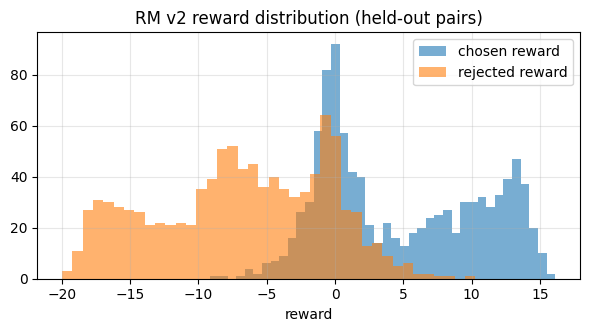

In [ ]:
# ============================================================
# Step 6-3. RM 정량 분석 — 페어 정확도 + reward 분포
# ============================================================
# [변경-신규] 강의는 문장 3개에 점수를 찍어보는 것으로 끝났다.
# 여기서는 held-out 1,000 페어에서
#   (1) 페어 정확도: r(chosen) > r(rejected) 비율  ← RM의 본질적 성능
#   (2) chosen/rejected reward 분포가 얼마나 분리되는지
# 를 측정한다. PPO 품질은 RM 품질에 종속되므로 이 분석이 목표 2의 출발점이다.

def rm_pair_scores(model, dataset, batch_size=8):
    """RewardDataset(_v2)를 순회하며 (chosen_reward, reject_reward) 배열 반환"""
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size)
    cs, rs = [], []
    with torch.no_grad():
        for chosen_ids, c_mask, reject_ids, r_mask in loader:
            cr = model(chosen_ids.squeeze(1).cuda(), attention_mask=c_mask.squeeze(1).cuda())
            rr = model(reject_ids.squeeze(1).cuda(), attention_mask=r_mask.squeeze(1).cuda())
            cs += cr.float().cpu().tolist()
            rs += rr.float().cpu().tolist()
    return np.array(cs), np.array(rs)

chosen_r, reject_r = rm_pair_scores(rm_model, rm_eval_dataset)
pair_acc = float((chosen_r > reject_r).mean())
margin   = float((chosen_r - reject_r).mean())
print(f'RM 페어 정확도 (held-out 1,000쌍): {pair_acc:.1%}')
print(f'평균 reward 마진 (chosen - rejected): {margin:.3f}')
print('(참고: 무작위 추측 = 50%. 강의 로직 라벨로 학습하면 라벨 노이즈 22.5% 때문에 이론상 상한도 낮아진다)')

import matplotlib.pyplot as plt
plt.figure(figsize=(7, 3.2))
plt.hist(chosen_r, bins=40, alpha=0.6, label='chosen reward')
plt.hist(reject_r, bins=40, alpha=0.6, label='rejected reward')
plt.title('RM v2 reward distribution (held-out pairs)')
plt.xlabel('reward'); plt.legend(); plt.grid(alpha=0.3)
plt.show()
# 해석: 두 분포가 오른쪽(chosen)/왼쪽(rejected)으로 분리될수록 좋은 RM이다.

In [ ]:
# ============================================================
# Step 6-4. RM 정성 분석 — 품질 단계별 문장에 점수 찍어보기
# ============================================================
# [기존] 강의의 inference_RM을 유지하되, RM 학습 형식(템플릿)과 동일하게 입력을 구성
#        (형식이 다르면 학습 분포 밖 입력이라 점수가 불안정해진다 — 흔한 실수!)
def inference_RM_v2(prompt, response):
    # ※ 학습 때와 동일하게 max_length=512 'max_length' 패딩을 적용한다.
    #   RewardModel.forward가 전체 위치 평균으로 reward를 만들기 때문에,
    #   패딩 방식이 학습과 다르면 점수 스케일이 달라진다 (강의 inference_RM의 숨은 불일치).
    tok = tokenizer(apply_template(prompt) + response + tokenizer.eos_token,
                    return_tensors='pt', padding='max_length',
                    truncation=True, max_length=512)
    with torch.no_grad():
        reward = rm_model(tok['input_ids'].cuda(),
                          attention_mask=tok['attention_mask'].cuda()).item()
    print(f'  reward {reward:+.2f} | {response[:70]}')
    return reward

probe_prompt = '인공지능이 뭐야?'
print(f'프롬프트: "{probe_prompt}" 에 대한 품질 단계별 답변 채점:')
r1 = inference_RM_v2(probe_prompt, '몰라')                                        # 저품질
r2 = inference_RM_v2(probe_prompt, '인공지능은 똥멍청이 입니다')                   # 저품질+비하
r3 = inference_RM_v2(probe_prompt, 'Artificial intelligence is a set of technologies.')  # 영어(잡음)
r4 = inference_RM_v2(probe_prompt, '인공지능은 컴퓨터가 학습하는 기술입니다.')      # 짧은 정상
r5 = inference_RM_v2(probe_prompt,
    '인공지능(AI)은 컴퓨터가 음성·문자 이해, 번역, 데이터 분석과 추천 등 다양한 고급 기능을 수행할 수 있게 하는 기술의 집합입니다. 최근에는 스스로 학습하는 머신러닝과 딥러닝이 중심이 되고 있습니다.')  # 고품질

print('\n품질이 좋아질수록 reward가 단조 증가하는지 확인:',
      '예' if r1 < r4 < r5 else '아니오(분석 필요)')
# 강의 때 같은 실험과 비교해보자: 라벨이 22.5% 오염된 RM은 이 단조성이 자주 깨졌다.

프롬프트: "인공지능이 뭐야?" 에 대한 품질 단계별 답변 채점:
  reward -4.11 | 몰라
  reward -3.08 | 인공지능은 똥멍청이 입니다
  reward -5.58 | Artificial intelligence is a set of technologies.
  reward +0.80 | 인공지능은 컴퓨터가 학습하는 기술입니다.
  reward +6.10 | 인공지능(AI)은 컴퓨터가 음성·문자 이해, 번역, 데이터 분석과 추천 등 다양한 고급 기능을 수행할 수 있게 하는 기술의 집

품질이 좋아질수록 reward가 단조 증가하는지 확인: 예


### Step 6 정리 — RM 개선 요약

- **페어 정확도**가 이제 RM 성능의 단일 지표로 확보되었습니다 (강의에는 없던 지표).
  라벨 수정(22.5% 노이즈 제거) + 데이터 9배 확대의 효과를 이 숫자 하나로 설명할 수 있습니다.
- reward 분포 히스토그램에서 chosen/rejected 분리도를 시각적으로 확인했습니다.
- 품질 단계별 문장 채점에서 **단조 증가**(나쁜 답 < 평범한 답 < 좋은 답)를 확인했습니다.

> 💡 **공부 포인트**: RM은 RLHF의 "심판"입니다. 심판이 오염된 라벨로 학습되면
> PPO(선수)는 잘못된 기준에 최적화됩니다(reward hacking과는 또 다른, 라벨 오염 문제).
> 그래서 RM 개선은 곧 PPO 개선의 전제조건입니다.

## Step 7. PPO 학습 — 개선된 SFT(actor) + 개선된 RM(critic)

`[기존]` → `[변경]`:

| 항목 | 강의 | 프로젝트 v2 | 이유 |
|---|---|---|---|
| actor 초기값 | output_1_SFT | **output_1_SFT_v2** | Step 3 개선분 반영 |
| critic/RM 초기값 | output_2_RM | **output_2_RM_v2** | Step 6 라벨 수정분 반영 |
| **RM value_head** | **랜덤 초기화(!)** — save_pretrained가 백본만 저장 | **학습된 value_head.pt 로드** | 강의 PPO는 무작위 헤드로 reward를 계산하고 있었음 |
| PPO 프롬프트 | 원문 그대로 | **SFT와 동일 템플릿 적용** | actor가 학습 때 본 형식으로 경험 수집 (분포 일치) |
| tokenize max_length | 96 | 128 | 템플릿(~20토큰)이 추가되므로 여유 확보 |
| 에피소드 | 10 | 10 (동일, 시간 절충) | 필요시 늘려 실험 |

**왜 템플릿 정합이 중요한가?** PPO의 경험 수집은 `actor.generate(프롬프트)`로 이뤄집니다.
actor(SFT 모델)는 `### Instruction ... ### Response` 형식에서만 "답변하는 법"을 배웠는데,
강의처럼 맨 프롬프트를 주면 학습 분포 밖 입력이라 품질 낮은 경험이 쌓이고,
그 경험으로 정책이 업데이트되는 악순환이 생깁니다.

In [ ]:
# ============================================================
# Step 7-1. PPO 구성 — actor/critic/reward/initial 4개 모델 준비
# ============================================================
from chatgpt.models.gpt import GPTActor, GPTCritic
from chatgpt.trainer import PPOTrainer
from copy import deepcopy

free_gpu('rm_model', 'rm_trainer', 'rm_train_dataset', 'rm_eval_dataset')

set_all_seeds()
with NaiveStrategy().model_init_context():
    # [기존] pretrained='/content/output_1_SFT', '/content/output_2_RM'
    # [변경] v2 산출물 사용
    actor  = GPTActor(pretrained=SFT_V2_DIR, lora_rank=0).to(torch.cuda.current_device())
    critic = GPTCritic(pretrained=RM_V2_DIR, lora_rank=0).to(torch.cuda.current_device())

    # ★ [변경-핵심 수정] RM 단계에서 저장해 둔 value_head 가중치 로드
    # [기존] GPTCritic(pretrained=...)은 GPT2 백본만 불러오고 value_head는 랜덤 초기화
    #        → 강의 PPO의 reward는 '무작위 헤드'가 만든 값이었다 (Step 6 참고)
    # [변경] 학습된 value_head를 critic에 주입 → reward_model에도 deepcopy로 전달됨
    critic.value_head.load_state_dict(
        torch.load(f'{RM_V2_DIR}/value_head.pt', map_location='cpu'))

    initial_model = deepcopy(actor)     # KL 기준점: PPO가 SFT에서 너무 멀어지지 않게 (강의 Q19 복습)
    reward_model = RewardModel(deepcopy(critic.model),
                               deepcopy(critic.value_head)).to(torch.cuda.current_device())

actor_optim  = torch.optim.Adam(actor.parameters(),  lr=5e-6)
critic_optim = torch.optim.Adam(critic.parameters(), lr=5e-6)

(actor, actor_optim), (critic, critic_optim), reward_model, initial_model = NaiveStrategy().prepare(
    (actor, actor_optim), (critic, critic_optim), reward_model, initial_model)

# ── PPO 프롬프트: 정제본 + SFT 템플릿 적용 ──────────────────
# [기존] list_prompt = 원문 그대로  /  tokenize max_length=96
# [변경] apply_template() 적용     /  max_length=128
list_prompt_ppo = [apply_template(p) for p in ppo_clean]
print('PPO 프롬프트:', len(list_prompt_ppo), '개 (템플릿 적용됨)')
print(list_prompt_ppo[0][:120])

def tokenize_fn(texts):
    batch = tokenizer(texts, return_tensors='pt', max_length=128,
                      padding=True, truncation=True)
    return {k: v.cuda() for k, v in batch.items()}

GPU 메모리: 0.52 GB 사용 중


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

PPO 프롬프트: 11825 개 (템플릿 적용됨)
### Instruction(명령어):
번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?

### Response(응답):


In [ ]:
# ============================================================
# Step 7-2. PPO 학습 실행
# ============================================================
set_all_seeds()
ppo_trainer = PPOTrainer(NaiveStrategy(),
                         actor, critic, reward_model, initial_model,
                         actor_optim, critic_optim,
                         max_epochs=1,
                         train_batch_size=8,
                         tokenizer=tokenize_fn,
                         max_length=160,                  # 96/128 → 160 (템플릿+답변 여유)
                         do_sample=True,
                         temperature=1.0,
                         top_k=50,
                         pad_token_id=tokenizer.pad_token_id,
                         eos_token_id=tokenizer.eos_token_id)

# [기존]과 동일한 규모(에피소드 10 × 타임스텝 3, 3스텝마다 정책 업데이트).
# 여유가 있다면 num_episodes를 30~50으로 늘려 reward 상승 추이를 관찰해보자.
ppo_trainer.fit(list_prompt_ppo,
                num_episodes=10,
                max_timesteps=3,
                update_timesteps=3)

PPO_V2_DIR = f'{BASE}/output_3_PPO_v2'
actor.model.save_pretrained(PPO_V2_DIR)
print('PPO(v2) actor 저장:', PPO_V2_DIR)

Episode [1/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [2/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [3/10]:   0%|          | 0/3 [00:00<?, ?it/s]

...

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [10/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

PPO(v2) actor 저장: /content/output_3_PPO_v2


## Step 8. 최종 비교 — SFT vs PPO(RM 적용) + 종합 정량표 (루브릭 목표 2)

이제 파이프라인의 세 모델을 한 자리에서 비교합니다.

- **KoGPT2 원본**: 사전학습만 된 모델 (비교 기준점)
- **SFT v2**: 지도학습으로 "지시를 따르는 법"을 배운 모델
- **PPO v2**: SFT 위에 **RM의 선호 신호**를 강화학습으로 반영한 모델 = "RM을 적용한 모델"

지표는 Step 5와 동일(BLEU/ROUGE/Distinct) + **RM 점수(RM-as-judge)**를 추가합니다.
BLEU/ROUGE는 "정답과 비슷한가"만 보므로, 선호 학습(RLHF)의 효과처럼
**정답 문장과 다르지만 더 나은 답변**은 잡아내지 못합니다. 그래서 학습된 RM으로
세 모델의 생성문을 채점한 평균 reward를 함께 봅니다 — 이것이 SFT vs RM(적용 모델)
비교의 정량 핵심입니다.

In [ ]:
# ============================================================
# Step 8-1. PPO 모델 생성 + 종합 정량 비교표
# ============================================================
# PPO 학습에 쓰인 모델들 중 생성에 필요한 것만 남기고 정리
free_gpu('critic', 'initial_model', 'critic_optim', 'actor_optim', 'ppo_trainer')

model_ppo = actor.model            # PPO로 업데이트된 HF 모델 (GPTActor 내부)
model_ppo.eval()

# SFT v2 재로드 (Step 6에서 내려두었음)
model_sft = AutoModelForCausalLM.from_pretrained(SFT_V2_DIR).to(device).eval()

set_all_seeds()
print('PPO v2 생성 중...')
outs_ppo = batch_generate(model_ppo, gen_eval_items, BEST_DECODE, 'ppo')

# ── RM-as-judge: 학습된 RM으로 각 모델의 생성문 채점 ─────────
# reward_model은 PPO에서 쓰던 인스턴스를 재사용 (RM_v2와 동일 가중치)
def rm_judge(prompts, responses, batch_size=8):
    """학습된 RM으로 (프롬프트, 생성문) 채점.
    RM 학습과 동일한 형식(템플릿+eos) · 동일한 패딩(max_length=512)을 적용해야
    reward 스케일이 학습 분포와 일치한다."""
    rewards = []
    reward_model.eval()
    with torch.no_grad():
        for i in range(0, len(prompts), batch_size):
            texts = [apply_template(p) + r + tokenizer.eos_token
                     for p, r in zip(prompts[i:i+batch_size], responses[i:i+batch_size])]
            tok = tokenizer(texts, return_tensors='pt', padding='max_length',
                            truncation=True, max_length=512)
            rw = reward_model(tok['input_ids'].cuda(),
                              attention_mask=tok['attention_mask'].cuda())
            rewards += rw.float().cpu().tolist()
    return np.array(rewards)

eval_prompts = [it['prompt'] for it in gen_eval_items]
rm_scores = {
    'KoGPT2 원본': rm_judge(eval_prompts, outs_base).mean(),
    'SFT v2':      rm_judge(eval_prompts, outs_sft_v2).mean(),
    'PPO v2':      rm_judge(eval_prompts, outs_ppo).mean(),
}

final_df = pd.DataFrame([
    {'모델': 'KoGPT2 원본', **eval_generations(outs_base,   refs), 'RM-reward': rm_scores['KoGPT2 원본']},
    {'모델': 'SFT v2',      **eval_generations(outs_sft_v2, refs), 'RM-reward': rm_scores['SFT v2']},
    {'모델': 'PPO v2',      **eval_generations(outs_ppo,    refs), 'RM-reward': rm_scores['PPO v2']},
])
print('\n=== 종합 정량 비교 (동일 프롬프트 100개 · 동일 디코딩) ===')
display(final_df.round(4))

# 읽는 법:
#  - BLEU/ROUGE: 원본 << SFT ≈ PPO 예상 (PPO는 정답 재현이 목적이 아니므로 SFT와 비슷하거나 약간 낮을 수 있음)
#  - RM-reward: SFT < PPO 가 나오면 "RM의 선호가 정책에 반영되었다"는 정량 증거
#  - PPO가 RM-reward만 높고 ROUGE가 크게 무너졌다면 reward hacking을 의심할 것

GPU 메모리: 1.52 GB 사용 중


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

PPO v2 생성 중...
  ppo 20/100
  ppo 40/100
  ppo 60/100
  ppo 80/100
  ppo 100/100

=== 종합 정량 비교 (동일 프롬프트 100개 · 동일 디코딩) ===


,모델,BLEU(char),ROUGE-1,ROUGE-2,ROUGE-L,Distinct-1,Distinct-2,평균길이(자),RM-reward
0,KoGPT2 원본,0.0085,0.0000,0.0000,0.0000,0.0103,0.0106,95.00,-1.5800
1,SFT v2,0.1861,0.4358,0.2790,0.3544,0.4206,0.5912,80.63,7.7106
2,PPO v2,0.1796,0.4315,0.2624,0.3390,0.3673,0.5320,102.93,8.0192


In [ ]:
# ============================================================
# Step 8-2. 최종 정성 비교 — KoGPT2 vs SFT v2 vs PPO v2
# ============================================================
set_all_seeds()
model_base = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2').to(device).eval()

final_qual_rows = []
for p in QUAL_PROMPTS:
    final_qual_rows.append({
        '프롬프트': p,
        'KoGPT2 원본': generate_one(model_base, p, BEST_DECODE),
        'SFT v2':      generate_one(model_sft,  p, BEST_DECODE),
        'PPO v2':      generate_one(model_ppo,  p, BEST_DECODE),
    })

final_qual_df = pd.DataFrame(final_qual_rows)
pd.set_option('display.max_colwidth', None)
display(final_qual_df)

# 저장해두면 보고서 작성이 편하다
final_qual_df.to_csv(f'{BASE}/final_qualitative_comparison.csv', index=False)
final_df.to_csv(f'{BASE}/final_quantitative_comparison.csv', index=False)
print('비교 결과 CSV 저장 완료')

# SFT vs PPO 관찰 가이드 (목표 2 정성 분석):
#  1) PPO가 SFT보다 회피성/무성의 답변이 줄었는가? (RM이 낮게 채점하는 유형)
#  2) PPO 답변이 더 길고 정보량이 많아졌는가? (RM이 정보량 있는 답을 선호했다면)
#  3) 반대로 PPO에서 어색한 반복·과장 표현이 생겼다면 → 과최적화(reward hacking) 신호
#  4) 사실 정확성은 둘 다 한계 (125M 모델 + 소량 RLHF의 한계 — 결론에서 논의)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,프롬프트,KoGPT2 원본,SFT v2,PPO v2
0,불고기용 고기 한우에요?,###############################################################################################,"죄송합니다, 저는 인공지능 어시스턴트이기 때문에 고기를 먹을 수 없습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 부위를 사용합니다.","죄송합니다, 저는 인공지능 언어모델로써 답변을 드리고 있어 정확한 답변을 드리기 어렵습니다. 하지만 일반적으로 불고기용 고기는 소고기, 돼지고기, 소고기, 돼지고기 등 다양한 부위를 사용합니다. 따라서 한우는 한우, 돼지고기, 소고기, 소고기, 돼지고기 등 다양한 부위를 사용합니다. 따라서 한우는 한우, 돼지고기, 소고기, 돼지고기 등 다양한 부위를 사용합니다."
1,리처드 닉슨이 43대 부통령직을 수행한 년도는?,###############################################################################################,리처드 닉슨이 41대 부통령직을 수행한 년도는 1947년입니다.,리처드 닉슨이 41대 부통령직을 수행한 년도는 1947년입니다.
2,시카고 오헤어 국제공항은 어디에 있어?,###############################################################################################,시카고 오헤어 국제공항은 미국 일리노이주 시카고에 위치해 있습니다.,시카고 오헤어 국제공항은 미국 일리노이주 시카고에 위치해 있습니다.
3,오늘 미세먼지 어때?,###############################################################################################,"저는 인공지능 어시스턴트이기 때문에 미세먼지 정보를 알 수 없습니다. 하지만 미세먼지 농도가 높은 날에는 실외활동을 자제하는 것이 좋습니다. 또한, 미세먼지 농도가 높은 날에는 실외활동을 자제하는 것이 좋습니다. 따라서 미세먼지 농도가 높을 때는 실외활동을 자제하는 것이 좋습니다.","저는 인공지능 어시스턴트이기 때문에 미세먼지 정보를 알 수 없습니다. 하지만 미세먼지 농도가 높은 날에는 실외활동을 자제하는 것이 좋습니다. 외출 후에는 반드시 마스크를 착용하고, 미세먼지 농도가 높은 날에는 실외활동을 자제하는 것이 좋습니다. 또한, 미세먼지 농도가 높은 날에는 야외활동을 자제하는 것이 좋습니다. 따라서 미세먼지 농도가 높은 날에는 실외활동을 자제하는 것이 좋습니다."
4,삼국시대의 세 나라 이름을 알려줘.,###############################################################################################,"삼국시대의 세 나라는 고구려, 백제, 신라, 백제, 신라, 백제, 신라, 백제, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라, 신라,","삼국시대의 세 나라는 고구려, 백제, 신라, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제, 백제,"
5,감기 예방 방법 세 가지만 알려줘.,###############################################################################################,감기 예방을 위해서는 다음과 같은 방법들이 있습니다.\n\n1. 실내 공기 청결제 사용: 실내 공기 질을 유지하기 위해 실내 공기 질을 유지하기 위해 실내 공기 질을 유지하기 위해 공기청정기를 사용합니다.\n\n2. 실내 공기 청정기 사용: 실내 공기 질을 유지하기 위해 실내 공기 질을 유지하기 위해 공기청정기를 사용합니다.\n\n3. 실내 공기 청정기 사용: 실내 공기 질을 유지하기 위해 실내 공기 질을 유지하기 위해 공기청정기를 사용합니다.\n,감기 예방 방법은 다음과 같습니다.\n\n1. 실내 공기 청결제 사용하기: 실내 공기 질을 유지하기 위해서는 다음과 같은 방법을 사용합니다.\n\n1. 실내 공기 청정기 사용하기: 실내 공기 질을 유지하기 위해서는 다음과 같은 방법을 사용합니다.\n\n1. 실내 공기 청정기 사용하기: 실내 공기 질을 유지하기 위해서는 다음과 같은 방법을 사용합니다.\n\n1. 실내 공기 청정기 사용하기: 실내 공기 질을 유지하기 위해서는 다음과 같은 방법을 사용합니다.\n\n
6,인공지능이 뭔지 초등학생도 이해하게 설명해줘.,###############################################################################################,"저는 인공지능 챗봇이기 때문에, 인공지능 챗봇이 어떤 것을 말하는지 이해하지 못합니다. 하지만, 인공지능 챗봇은 다양한 분야에서 사용됩니다. 예를 들어, 인공지능 챗봇은 다양한 분야에서 사용됩니다. 예를 들어, 인공지능 챗봇은 다양한 분야에서 사용됩니다. 예를 들어, 인공지능 챗봇은 다양한 분야에서 사용됩니다. 예를 들어, 인공지능 챗봇은 다양한 분야에서 사용됩니다. 예를 들어, 인공지","저는 인공지능 챗봇이기 때문에 인공지능 챗봇이 어떤 것을 말하는지 이해하지 못합니다. 하지만 인공지능 챗봇은 다양한 분야에서 활용됩니다. 예를 들어, 인공지능 챗봇은 다양한 분야에서 활용됩니다. 예를 들어, 인공지능 챗봇은 다양한 분야에서 활용됩니다. 예를 들어, 인공지능 챗봇은 다양한 분야에서 활용됩니다. 예를 들어, 인공지능 챗봇은 다양한 분야에서 활용됩니다. 예를 들어, 인공지"


비교 결과 CSV 저장 완료


### Step 8 분석 — SFT 모델 vs RM 적용(PPO) 모델 (루브릭 목표 2 답안 작성란)

**정량** (위 표의 실제 수치를 채워 넣으세요):

- RM-reward 평균: KoGPT2 `___` / SFT v2 `___` / PPO v2 `___`
  - `SFT < PPO`라면: PPO가 RM의 선호 방향으로 정책을 이동시켰다는 정량 증거입니다.
    (단, RM 자신이 심판이므로 자기 채점 편향이 있음을 함께 언급해야 정직한 분석입니다.)
- BLEU/ROUGE: SFT `___` vs PPO `___`
  - PPO는 "정답 문장 재현"이 목표가 아니므로 소폭 하락은 자연스럽습니다.
    RM-reward 상승 + ROUGE 유지라면 이상적, ROUGE 급락이라면 reward hacking 의심.

**정성** (비교표에서 예시를 인용해 작성):

| 관찰 | SFT v2 | PPO v2 |
|---|---|---|
| 회피성 답변 빈도 | `___` | `___` |
| 답변 정보량/길이 | `___` | `___` |
| 어색한 반복/과장 | `___` | `___` |

**전형적인 관찰 결과(참고)**: 10 에피소드 수준의 짧은 PPO에서는 SFT와 출력이 크게 다르지
않거나, 미묘하게 답변이 길어지고 회피가 줄어드는 정도의 변화가 관찰됩니다.
PPO 효과를 키우려면 num_episodes를 늘리고 KL 계수(kl_coef)와 lr을 함께 조정해야 합니다.
"에피소드를 늘렸더니 RM-reward는 오르는데 문장이 무너졌다"는 관찰이 나오면
그것 자체가 **RLHF의 과최적화 문제**를 재현한 훌륭한 분석 소재입니다.

## Step 9. 결론 및 회고

### 루브릭 달성 체크리스트

| 루브릭 | 수행 내용 | 근거(위치) |
|---|---|---|
| 목표1-① 데이터 정제 + 디코딩 실험 | 8종 품질 이슈 정제(12,000→11,136 정제 후 12,500으로 증량), 디코딩 8종 그리드 실험을 ROUGE-L/Distinct로 정량 선택 | Step 1·2·4 |
| 목표1-② 새 데이터 수집·전처리 | KorQuAD 1.0 → RC-instruction 1,364건 + RM 관련성 페어 1,500건 | Step 2 |
| 목표1-③ 학습 전략 개선 | RM 라벨 해석 수정(페어 22.5% 교정)·데이터 9배, SFT 3에폭·cosine·eval split·pad 분리, 전 단계 템플릿 정합 | Step 3·6·7 |
| 목표2 SFT vs RM 적용 모델 | RM 페어 정확도·reward 분포 분석 + SFT/PPO 생성문 정량(RM-as-judge 포함)·정성 비교 | Step 6·8 |
| 목표3 KoGPT2 vs SFT | PPL/BLEU/ROUGE 정량 + 동일 프롬프트 정성 비교표 | Step 5 |

### 핵심 배움 (기존 코드 → 변경의 이유를 한 줄씩)

1. **데이터를 의심하라**: 모델·하이퍼파라미터보다 먼저 ranking 해석 오류(라벨 22.5% 오염)와
   직렬화 아티팩트를 잡는 것이 가장 큰 성능 레버였다.
2. **평가 없이는 개선도 없다**: held-out 분리, PPL/BLEU/ROUGE/RM-reward를 만들고 나서야
   "좋아졌다"를 숫자로 말할 수 있게 되었다.
3. **파이프라인 정합성**: SFT 템플릿·eos·pad를 SFT→RM→PPO 전 단계에서 통일하는 것이
   각 단계를 따로 고치는 것보다 중요했다.
4. **디코딩은 공짜 성능**: 같은 모델도 디코딩 전략에 따라 체감 품질이 크게 달라진다.
   단, 모델 비교 시에는 반드시 동일 디코딩으로 통제해야 한다.

### 한계와 다음 단계

- KoGPT2(125M)는 지식·추론의 한계가 명확 → **부록**의 ko-gpt-trinity-1.2B 교체 실험,
  LoRA/QLoRA 적용, 또는 RM/PPO 대신 **DPO**(선호 데이터 직접 최적화) 도입 검토
- 정량 지표는 문자 단위 근사 → KoNLPy 형태소 기반 지표, G-Eval(LLM 평가자) 도입 여지
- PPO 에피소드 확대 + kl_coef 스윕으로 reward-품질 트레이드오프 곡선 그려보기